## Projet - Prediction des ventes hebdomadaire

## Dataset Walmart sales forecast

### Objectif

Le projet vise à consevoir un système intelligent capable de prévoir les ventes hebdomadaires dans les magasins de distribution à partir des données historiques. Le système exploitera les données historiques des ventes, les patterns temporels et saisonniers.

Plan du notebook:

1. Préparation de l'environnement de travail
2. Chargement, fusion et inspection du dataset
3. Analyse Exploratoire
4. Feature Engineering
5. Modélisation et évaluation
7. Deploiement



### 1. Preparation de l'environnement de travail

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit,learning_curve
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
        Dense, Dropout, LSTM, Conv1D, MaxPooling1D, Flatten, BatchNormalization
    )
pd.set_option("display.max_columns",None)


### 2. Chargement, Inspection et Fusion des tables et fusion

### 2.1.  Chargement et inspection

In [61]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
store = pd.read_csv("data/stores.csv")
features = pd.read_csv("data/features.csv")

In [62]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 13.3 MB


In [63]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [64]:
#Affichons les differentes boutiques
print(f"Listons les boutiques enregistrées dans le fichier train")
train["Store"].unique()

Listons les boutiques enregistrées dans le fichier train


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

In [65]:
#Affichons les informations de la table store
print("Affichons les informations sommaires de la table store")
store.info()

Affichons les informations sommaires de la table store
<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Store   45 non-null     int64
 1   Type    45 non-null     str  
 2   Size    45 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.2 KB


In [66]:
#Affichons les 5 premieres lignes
store.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [67]:
print("Affichons toutes les modalités disponible de la variable Store")
store["Store"].unique()

Affichons toutes les modalités disponible de la variable Store


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

In [68]:
features.info()

<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   str    
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), str(1)
memory usage: 712.0 KB


In [69]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


####  2.2.  Fusion des dataset

### A. Fusion du fichiers train, features et stores

In [70]:
df_train=pd.merge(train,
              store,
              how="left",
              on="Store",
                 indicator=True)
assert (df_train["_merge"]=="both").all()  #Cela nous permettra de verifier si tous les stores repertoriés dans train ont une correspondance dans Store
df_train=df_train.drop("_merge",axis=1) #Suppression de la colonne _merge après vérification
df_train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size
0,1,1,2010-02-05,24924.50,False,A,151315
1,1,1,2010-02-12,46039.49,True,A,151315
2,1,1,2010-02-19,41595.55,False,A,151315
3,1,1,2010-02-26,19403.54,False,A,151315
4,1,1,2010-03-05,21827.90,False,A,151315


In [71]:
df_train=pd.merge(df_train,
                 features,
                 how="left",
                 on=["Store","Date","IsHoliday"],
                 indicator=True)
#Statisques de fusion
merge_stats=df_train["_merge"].value_counts()
print("Statistiques de fusion ")
print(merge_stats)
print(f"Ligne de la table Train ayant héritées des NaN après fusion {(df_train['_merge']=='Left_only').sum()} ")
df_train=df_train.drop("_merge",axis=1)   #Suppression de la colonne d'audit
#Vérifions si les Holiday_x et Holiday_y correspondent
if "IsHoliday_x" in df_train.columns and "IsHoliday_y" in df_train.columns:
    no_matching=(df_train["IsHoliday_x"]!=df_train["IsHoliday_y"])
    if no_matching.sum()>0:
        print(f"Attention: { no_matching.sum() } lignes de IsHoliday_x ne correspondent pas à IsHoliday_y")
    # Harmonisation
    df_train["IsHoliday"]=df_train["IsHoliday_x"]| df_train["IsHoliday_y"]
    df_train=df_train.drop(["IsHoliday_x","IsHoliday_y"],axis=1)


df_train.info()

Statistiques de fusion 
_merge
both          421570
left_only          0
right_only         0
Name: count, dtype: int64
Ligne de la table Train ayant héritées des NaN après fusion 0 
<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Type          421570 non-null  str    
 6   Size          421570 non-null  int64  
 7   Temperature   421570 non-null  float64
 8   Fuel_Price    421570 non-null  float64
 9   MarkDown1     150681 non-null  float64
 10  MarkDown2     111248 non-null  float64
 11  MarkDown3     137091 non-null  float64
 12  MarkDown4     134967 non-null  float64
 13  MarkDown5     151432 non-null  float64
 14  CPI     

B. Fusion du fichier test features et stores

In [72]:
test.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


In [73]:
df_test=pd.merge(test,
              store,
              how="left",
              on="Store",
                 indicator=True)
assert (df_test["_merge"]=="both").all()  #Cela nous permettra de verifier si tous les stores repertoriés dans train ont une correspondance dans Store
df_test=df_test.drop("_merge",axis=1) #Suppression de la colonne _merge après vérification
df_test.head()

,Store,Dept,Date,IsHoliday,Type,Size
0,1,1,2012-11-02,False,A,151315
1,1,1,2012-11-09,False,A,151315
2,1,1,2012-11-16,False,A,151315
3,1,1,2012-11-23,True,A,151315
4,1,1,2012-11-30,False,A,151315


In [74]:
df_test=pd.merge(df_test,
                 features,
                 how="left",
                 on=["Store","Date"],
                 indicator=True)
#Statisques de fusion
merge_stats=df_test["_merge"].value_counts()
print("Statistiques de fusion ")
print(merge_stats)
print(f"Ligne de la table Test ayant héritées des NaN après fusion {(df_test['_merge']=='Left_only').sum()} ")
df_test=df_test.drop("_merge",axis=1)   #Suppression de la colonne d'audit
#Vérifions si les Holiday_x et Holiday_y correspondent
if "IsHoliday_x" in df_test.columns and "IsHoliday_y" in df_test.columns:
    no_matching=(df_test["IsHoliday_x"]!=df_test["IsHoliday_y"])
    if no_matching.sum()>0:
        print(f"Attention: { no_matching.sum() } lignes de IsHoliday_x ne correspondent pas à IsHoliday_y")
    # Harmonisation
    df_test["IsHoliday"]=df_test["IsHoliday_x"]| df_test["IsHoliday_y"]
    df_test=df_test.drop(["IsHoliday_x","IsHoliday_y"],axis=1)


df_test.head()

Statistiques de fusion 
_merge
both          115064
left_only          0
right_only         0
Name: count, dtype: int64
Ligne de la table Test ayant héritées des NaN après fusion 0 


,Store,Dept,Date,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,1,2012-11-02,A,151315,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,False
1,1,1,2012-11-09,A,151315,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,False
2,1,1,2012-11-16,A,151315,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,False
3,1,1,2012-11-23,A,151315,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,True
4,1,1,2012-11-30,A,151315,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,False


In [75]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         115064 non-null  int64  
 1   Dept          115064 non-null  int64  
 2   Date          115064 non-null  str    
 3   Type          115064 non-null  str    
 4   Size          115064 non-null  int64  
 5   Temperature   115064 non-null  float64
 6   Fuel_Price    115064 non-null  float64
 7   MarkDown1     114915 non-null  float64
 8   MarkDown2     86437 non-null   float64
 9   MarkDown3     105235 non-null  float64
 10  MarkDown4     102176 non-null  float64
 11  MarkDown5     115064 non-null  float64
 12  CPI           76902 non-null   float64
 13  Unemployment  76902 non-null   float64
 14  IsHoliday     115064 non-null  bool   
dtypes: bool(1), float64(9), int64(3), str(2)
memory usage: 12.4 MB


### 3. Exploration des données

### 3.1- Valeurs manquantes

In [76]:
print("Dataset informations")
print("*"*100)
print(f"Dimension du jeu d'entrainement: {df_train.shape}")
print(f"Dimension du jeu de test: {df_test.shape}")
print(f"Variables: {list(df_test.columns)}")
print("\n types de chacune des colonnes:")
print(df_train.dtypes)
print("*"*100)


Dataset informations
****************************************************************************************************
Dimension du jeu d'entrainement: (421570, 16)
Dimension du jeu de test: (115064, 15)
Variables: ['Store', 'Dept', 'Date', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

 types de chacune des colonnes:
Store             int64
Dept              int64
Date                str
Weekly_Sales    float64
IsHoliday          bool
Type                str
Size              int64
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
dtype: object
****************************************************************************************************


In [77]:
#Définissons une fonction missing value qui nous permettra d'afficher les valeurs manquantes
def missing_values(df):
  """
  Cette fonction prendra en paramètre un dataframe et affichera les colonnes ayant de valeurs manquantes
  et le pourcentage correspondant.
  """
  missing_summary=pd.DataFrame({
    "Missing_count":df.isna().sum(),
    "Missing_percent":(df.isna().mean()*100).round(2)

})
  missing_summary=missing_summary[missing_summary["Missing_count"]>0].sort_values("Missing_count",ascending=False)
  print("Sommaire des valeurs manquantes")
  print(missing_summary)
missing_values(df_train)

Sommaire des valeurs manquantes
           Missing_count  Missing_percent
MarkDown2         310322            73.61
MarkDown4         286603            67.98
MarkDown3         284479            67.48
MarkDown1         270889            64.26
MarkDown5         270138            64.08


**Puisque les valeurs manquantes ne concernes que les colonnnes dediées aux promtions analysons ce processus de manquement en filtrant les semaines ayant au moins une promotion et celle n'ayant aucune promotion**

**Ce qu'il faut constater ici c'est que les NaN présent dans les differentes colonnes de promotions ne sont pas en réalité des valeurs manquantes mais plutôt le signe d'une absence de promotions pour cette semaine là**

### Nous allons remplacer ces NaN par des 0 mais avant cela nous allons essayer de créer des nouvelles colonnes qui permettrons d'analyser l'impact des promotions sur les ventes

In [78]:
markdown_cols=["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]
df_train["Promotion_Active"]=(~df_train[markdown_cols].isnull().all(axis=1)).astype(int) #elle vaudra 1 si la semaine possède une promotion et 0 sinon
df_train["Nombre_Promotion"]=df_train[markdown_cols].notna().sum(axis=1)
#Determinons laquelles des promotions est réellement acctive
for col in markdown_cols:
    df_train[f"{col}_Active"]=df_train[col].notna().astype(int)
#Maintenant remplacons les NAN par 0
df_train[markdown_cols]=df_train[markdown_cols].fillna(0)
print("\n Profil des promotions par semaines: ")
print(f"Environ {df_train['Promotion_Active'].mean()*100:.1f}% des semaines possèdent au moins une promotion")


 Profil des promotions par semaines: 
Environ 35.9% des semaines possèdent au moins une promotion


In [79]:
df_train[df_train["Nombre_Promotion"]!=0] #combien de semaines sont influencées par les promotions

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Promotion_Active,Nombre_Promotion,MarkDown1_Active,MarkDown2_Active,MarkDown3_Active,MarkDown4_Active,MarkDown5_Active
92,1,1,2011-11-11,18689.54,False,A,151315,59.11,3.297,10382.90,6115.67,215.07,2406.62,6551.42,217.998085,7.866,1,5,1,1,1,1,1
93,1,1,2011-11-18,19050.66,False,A,151315,62.25,3.308,6074.12,254.39,51.98,427.39,5988.57,218.220509,7.866,1,5,1,1,1,1,1
94,1,1,2011-11-25,20911.25,True,A,151315,60.14,3.236,410.31,98.00,55805.51,8.00,554.92,218.467621,7.866,1,5,1,1,1,1,1
95,1,1,2011-12-02,25293.49,False,A,151315,48.91,3.172,5629.51,68.00,1398.11,2084.64,20475.32,218.714733,7.866,1,5,1,1,1,1,1
96,1,1,2011-12-09,33305.92,False,A,151315,43.93,3.158,4640.65,19.00,105.02,3639.42,14461.82,218.961846,7.866,1,5,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,1,5,1,1,1,1,1
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,0.00,18.82,2253.43,2340.01,192.170412,8.667,1,4,1,0,1,1,1
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,0.00,7.89,599.32,3990.54,192.327265,8.667,1,4,1,0,1,1,1
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,0.00,3.18,437.73,1537.49,192.330854,8.667,1,4,1,0,1,1,1


In [80]:
pd.set_option("display.max_columns",None)
df_train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Promotion_Active,Nombre_Promotion,MarkDown1_Active,MarkDown2_Active,MarkDown3_Active,MarkDown4_Active,MarkDown5_Active
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0,0,0,0,0,0,0
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,0,0,0,0,0,0,0
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,0,0,0,0,0,0,0
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,0,0,0,0,0,0,0
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,0,0,0,0,0,0,0


### 3.2- Nombre de departement par store

In [81]:
print("*"*80)
print(f"Il existe très exactement { df_train['Dept'].nunique() } departements au sein de ce jeu de données")
print(f"Il existe très exactement { df_train['Store'].nunique() } stores au sein de ce jeu de données")
print("*"*80)

********************************************************************************
Il existe très exactement 81 departements au sein de ce jeu de données
Il existe très exactement 45 stores au sein de ce jeu de données
********************************************************************************


In [82]:
print("*"*60)
print(f"Explorons certaines colonnes plus en profondeur")
#Verifions s'il des valeurs négative ou nulles dans la variables Weekly_Sales
var_neg=(df_train["Weekly_Sales"]<=0).any() # Valeur booléen s'il au moins une valeur de Weekly_Sale est nulle ou négative
if var_neg: #si l'assertion est vrai affichons les lignes concernées
    print("La variable Weekly_Sales possèdes au moins une valeur negative ou nulle")
    print(f"Nombre de valeurs negatives ou nulles détectées: {df_train[df_train['Weekly_Sales']<=0].shape[0]}")
    Weekly_sales_neg=df_train[df_train['Weekly_Sales']<=0]
    print(f"Pourcentage de lignes donc la colonne Weekly_Sales est négative ou nulle: {(Weekly_sales_neg.shape[0]/df_train.shape[0])*100}%")
    print("*"*60)
    display(Weekly_sales_neg)

else:
    print("Toutes les valeurs de la variable WeeKly_Sales sont positives")

************************************************************
Explorons certaines colonnes plus en profondeur
La variable Weekly_Sales possèdes au moins une valeur negative ou nulle
Nombre de valeurs negatives ou nulles détectées: 1358
Pourcentage de lignes donc la colonne Weekly_Sales est négative ou nulle: 0.3221291837654482%
************************************************************


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Promotion_Active,Nombre_Promotion,MarkDown1_Active,MarkDown2_Active,MarkDown3_Active,MarkDown4_Active,MarkDown5_Active
846,1,6,2012-08-10,-139.65,False,A,151315,85.05,3.494,11436.22,245.0,6.85,6964.26,4836.22,221.958433,6.908,1,5,1,1,1,1,1
2384,1,18,2012-05-04,-1.27,False,A,151315,75.55,3.749,21290.13,0.0,69.89,4977.35,3261.04,221.671800,7.143,1,4,1,0,1,1,1
6048,1,47,2010-02-19,-863.00,False,A,151315,39.93,2.514,0.00,0.0,0.00,0.00,0.00,211.289143,8.106,0,0,0,0,0,0,0
6049,1,47,2010-03-12,-698.00,False,A,151315,57.79,2.667,0.00,0.0,0.00,0.00,0.00,211.380643,8.106,0,0,0,0,0,0,0
6051,1,47,2010-10-08,-58.00,False,A,151315,63.93,2.633,0.00,0.0,0.00,0.00,0.00,211.746754,7.838,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419597,45,80,2010-02-12,-0.43,True,B,118221,27.73,2.773,0.00,0.0,0.00,0.00,0.00,181.982317,8.992,0,0,0,0,0,0,0
419598,45,80,2010-02-19,-0.27,False,B,118221,31.27,2.745,0.00,0.0,0.00,0.00,0.00,182.034782,8.992,0,0,0,0,0,0,0
419603,45,80,2010-04-16,-1.61,False,B,118221,54.28,2.899,0.00,0.0,0.00,0.00,0.00,181.692477,8.899,0,0,0,0,0,0,0
419614,45,80,2010-07-02,-0.27,False,B,118221,76.61,2.815,0.00,0.0,0.00,0.00,0.00,182.318780,8.743,0,0,0,0,0,0,0


**Une semaine enregistrant des ventes negatives ou nulle serait certaine liée à un problème d'enregistrement car cela semble irréaliste d'enregistrer des ventes négatives ou nulle durant toute une semaine ou alors cela voudrait signifier qu'il y a eu plus de retour que de ventes durant cette semaine. Nous comptons 1358 lignes ayant ce potentiel problème. Puisque l'hypothèse selon laquelle ces valeur pourrait représenter une perte ou simplement une semaine sans vente nous allons créer une nouvelle variable binaire is_vente qui sera égale à 1 si la vente est strictement positive et 0 sinon**

### 3.3- Creation d'une variable Flag Is_Vente

In [83]:
df_train["Is_Vente"]=(~(df_train["Weekly_Sales"]<=0)).astype(int) #Cela nous permettra de savoir s'il y a effectivement vente au cours de la semaine
df_train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Promotion_Active,Nombre_Promotion,MarkDown1_Active,MarkDown2_Active,MarkDown3_Active,MarkDown4_Active,MarkDown5_Active,Is_Vente
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0,0,0,0,0,0,0,1
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,0,0,0,0,0,0,0,1
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,0,0,0,0,0,0,0,1
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,0,0,0,0,0,0,0,1
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,0,0,0,0,0,0,0,1


## 3.4- Examinons la colonne Date

In [84]:
print("*"*60)
print("affichons la date de debut de collecte des données et la date de fin ")
print(df_train['Date'].head(5))
df_train['Date'].tail()

************************************************************
affichons la date de debut de collecte des données et la date de fin 
0    2010-02-05
1    2010-02-12
2    2010-02-19
3    2010-02-26
4    2010-03-05
Name: Date, dtype: str


421565    2012-09-28
421566    2012-10-05
421567    2012-10-12
421568    2012-10-19
421569    2012-10-26
Name: Date, dtype: str

**Les données ont été collectées du 5 février 2010 au 26 octobre 2012 pour la suite de notre analyse nous allons convertir cette variable
en format datetime afin d'en créer de nouvelles colonnes**

In [85]:
print("Identifions les fêtes considérées dans notre jeu de données")
isholiday=df_train.loc[df_train["IsHoliday"]==True] #filtrons uniquement les lignes des semaines de fête
#Determinons toutes les differentes dates associées à cette fêtes
print(f"Nombre de semaines ordinaires: {df_train['Date'].nunique()-isholiday['Date'].nunique()}")
print(f"Nombre de semaine ayant une fête: {isholiday['Date'].nunique()}")
isholiday["Date"].unique()

Identifions les fêtes considérées dans notre jeu de données
Nombre de semaines ordinaires: 133
Nombre de semaine ayant une fête: 10


<StringArray>
['2010-02-12', '2010-09-10', '2010-11-26', '2010-12-31', '2011-02-11',
 '2011-09-09', '2011-11-25', '2011-12-30', '2012-02-10', '2012-09-07']
Length: 10, dtype: str

Il s'agit principalement :

* Du **Super Bowl** :12-Fev-2010, 11-Fev-2011 et 10-Fev-2012
* Du **Labor Day** 10-Sep-2010, 09-Sep-2011 et 07-Sep-2012
* De la fête de **Thanksgiving** 26-Nov-2010, 25-Nov-2011
* De la fête de **Noel** 31-Dec-2010 et 30-Dec-2011

Nous constatons entre autre l'année 2012 ne contient pas le dermier trimistre de l'année. De plus la semaine de noel est désignée comme étant la derniere de l'année.

Nous allons determiné la semaine de noel comme étant la 51 ieme de chaque année 

**Afin de mieux analyser impact de ces fêtes sur le chiffre d'affaire hebdomadaire nous allons créer une nouvelle colonne qui donnera laquelle des fêtes il s'agit en fonction de la date ainsi on saura laquelle influence le plus les ventes**

### 3.5- Creation des variables is_Thanksgiving, Is_Chrismas, Is_SuperBowl et Is_LaborDay

In [86]:
superbowl_date=["2010-02-12","2011-02-11","2012-02-10"]
labor_date=["2010-09-10","2011-09-09","2012-09-07"]
noel_date=["2010-12-24","2011-12-23"]
thank_date=["2010-11-26","2011-11-25"]
df_train["Is_SuperBowl"]=df_train["Date"].isin(superbowl_date).astype(int)
df_train["Is_LaborDay"]=df_train["Date"].isin(labor_date).astype(int)
df_train["Is_Chrismas"]=df_train["Date"].isin(noel_date).astype(int)
df_train["Is_Thankgiving"]=df_train["Date"].isin(thank_date).astype(int)
df_train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Promotion_Active,Nombre_Promotion,MarkDown1_Active,MarkDown2_Active,MarkDown3_Active,MarkDown4_Active,MarkDown5_Active,Is_Vente,Is_SuperBowl,Is_LaborDay,Is_Chrismas,Is_Thankgiving
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0,0,0,0,0,0,0,1,0,0,0,0
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,0,0,0,0,0,0,0,1,1,0,0,0
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,0,0,0,0,0,0,0,1,0,0,0,0
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,0,0,0,0,0,0,0,1,0,0,0,0
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,0,0,0,0,0,0,0,1,0,0,0,0


### 3.6- Création des variables temporelles et des variables

In [87]:
## Etape 1 convertissons la date en format datetime
df_train["Date"]=pd.to_datetime(df_train["Date"])
df_train.info()
## Etape 2 Création des variables years, Mounth et Week
df_train["Years"]=df_train["Date"].dt.year
df_train["Mois"]=df_train["Date"].dt.month_name()
df_train["Week"]=df_train["Date"].dt.isocalendar().week
df_train.head()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 28 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Store             421570 non-null  int64         
 1   Dept              421570 non-null  int64         
 2   Date              421570 non-null  datetime64[us]
 3   Weekly_Sales      421570 non-null  float64       
 4   IsHoliday         421570 non-null  bool          
 5   Type              421570 non-null  str           
 6   Size              421570 non-null  int64         
 7   Temperature       421570 non-null  float64       
 8   Fuel_Price        421570 non-null  float64       
 9   MarkDown1         421570 non-null  float64       
 10  MarkDown2         421570 non-null  float64       
 11  MarkDown3         421570 non-null  float64       
 12  MarkDown4         421570 non-null  float64       
 13  MarkDown5         421570 non-null  float64       
 14  CPI            

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Promotion_Active,Nombre_Promotion,MarkDown1_Active,MarkDown2_Active,MarkDown3_Active,MarkDown4_Active,MarkDown5_Active,Is_Vente,Is_SuperBowl,Is_LaborDay,Is_Chrismas,Is_Thankgiving,Years,Mois,Week
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0,0,0,0,0,0,0,1,0,0,0,0,2010,February,5
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,0,0,0,0,0,0,0,1,1,0,0,0,2010,February,6
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,0,0,0,0,0,0,0,1,0,0,0,0,2010,February,7
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,0,0,0,0,0,0,0,1,0,0,0,0,2010,February,8
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,0,0,0,0,0,0,0,1,0,0,0,0,2010,March,9


In [88]:
df_noel=df_train.loc[df_train["Week"]==51,"Date"]
print(df_noel.unique())

<DatetimeArray>
['2010-12-24 00:00:00', '2011-12-23 00:00:00']
Length: 2, dtype: datetime64[us]


### 3.7- Inspection des markdows

In [89]:
has_negative = (df_train[markdown_cols] < 0).any().any()
neg_rows = df_train[(df_train[markdown_cols] < 0).any(axis=1)]
if has_negative:
    display(neg_rows[neg_rows["MarkDown2"]<0])

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Promotion_Active,Nombre_Promotion,MarkDown1_Active,MarkDown2_Active,MarkDown3_Active,MarkDown4_Active,MarkDown5_Active,Is_Vente,Is_SuperBowl,Is_LaborDay,Is_Chrismas,Is_Thankgiving,Years,Mois,Week
29629,4,1,2012-03-23,37148.64,False,A,205863,59.07,3.759,8806.80,-10.5,5.99,739.14,4396.97,130.896645,4.607,1,5,1,1,1,1,1,1,0,0,0,0,2012,March,12
29772,4,2,2012-03-23,94894.85,False,A,205863,59.07,3.759,8806.80,-10.5,5.99,739.14,4396.97,130.896645,4.607,1,5,1,1,1,1,1,1,0,0,0,0,2012,March,12
29915,4,3,2012-03-23,11416.47,False,A,205863,59.07,3.759,8806.80,-10.5,5.99,739.14,4396.97,130.896645,4.607,1,5,1,1,1,1,1,1,0,0,0,0,2012,March,12
30058,4,4,2012-03-23,53921.90,False,A,205863,59.07,3.759,8806.80,-10.5,5.99,739.14,4396.97,130.896645,4.607,1,5,1,1,1,1,1,1,0,0,0,0,2012,March,12
30201,4,5,2012-03-23,43779.18,False,A,205863,59.07,3.759,8806.80,-10.5,5.99,739.14,4396.97,130.896645,4.607,1,5,1,1,1,1,1,1,0,0,0,0,2012,March,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390864,41,97,2012-08-24,23337.75,False,A,196321,69.07,3.558,6068.27,-20.0,85.74,3710.05,2287.85,198.098420,6.432,1,5,1,1,1,1,1,1,0,0,0,0,2012,August,34
390995,41,98,2012-06-01,10433.00,False,A,196321,57.29,3.764,9160.25,-2.0,127.56,1850.68,2652.68,197.621895,6.547,1,5,1,1,1,1,1,1,0,0,0,0,2012,June,22
391007,41,98,2012-08-24,9822.45,False,A,196321,69.07,3.558,6068.27,-20.0,85.74,3710.05,2287.85,198.098420,6.432,1,5,1,1,1,1,1,1,0,0,0,0,2012,August,34
391041,41,99,2012-06-01,29.88,False,A,196321,57.29,3.764,9160.25,-2.0,127.56,1850.68,2652.68,197.621895,6.547,1,5,1,1,1,1,1,1,0,0,0,0,2012,June,22


### Exploration des données

## A. Analyse globale de corrélation

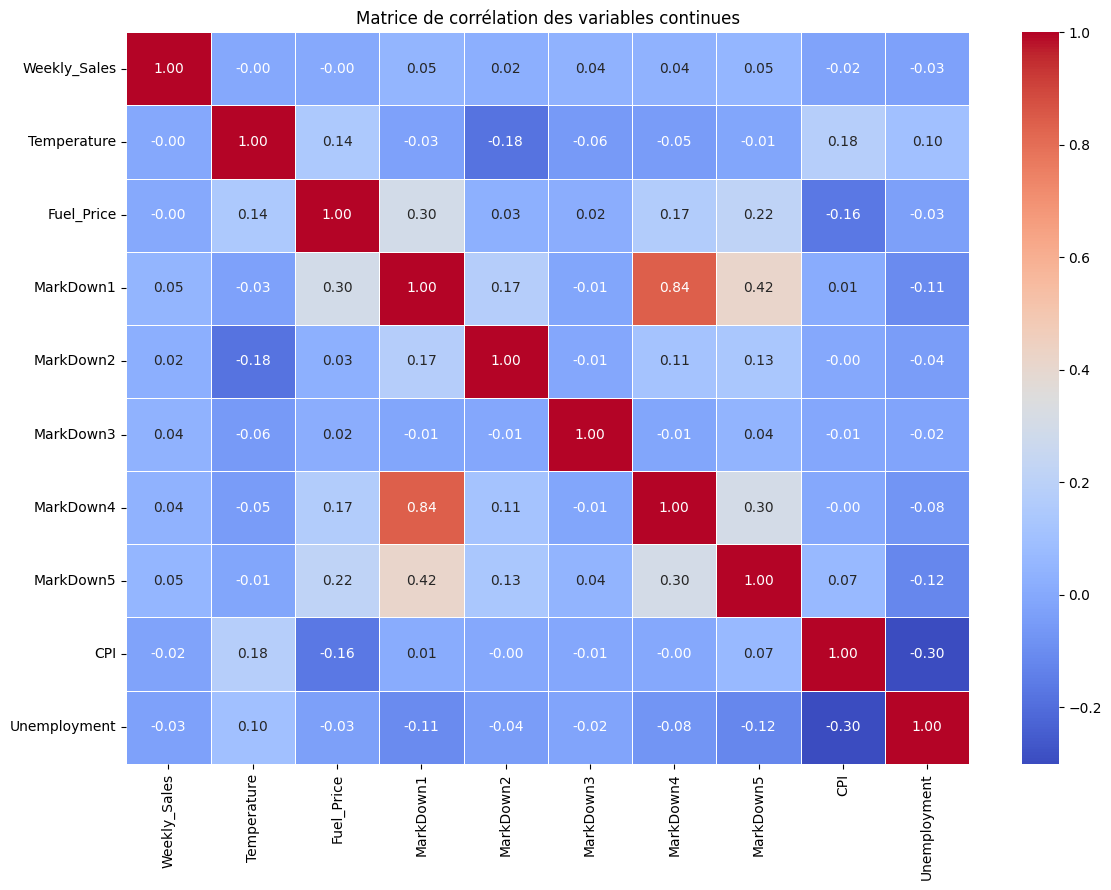

In [90]:
var_num=df_train.select_dtypes(include=["float64"]).columns
# matrice de corrélation des variables numériques
corr=df_train[var_num].corr()
plt.figure(figsize=(12,9))
sns.heatmap(corr,
           cmap="coolwarm",
           annot=True,
           linewidths=0.5,
           linecolor="white",
           fmt=".2f")
plt.title("Matrice de corrélation des variables continues")
plt.tight_layout()
plt.show()

### B. Etude de l'impact des semaines de fête sur les ventes

In [91]:
moy_vente=df_train.groupby("IsHoliday")["Weekly_Sales"].mean()
print("Moyenne des ventes par semaine en fonction des vente")
df_mean=pd.DataFrame(moy_vente)
df_mean.columns=["Moyenne_Vente"]
df_mean

Moyenne des ventes par semaine en fonction des vente


,Moyenne_Vente
IsHoliday,
False,15901.445069
True,17035.823187


**On constate que les semaines de fêtes sont celle qui enregistre le plus de vente en moyenne et puisqu'on en denombre juste 10 on peut conclure que les semaines de fête sont très importantes par rapport aux autres semaines**

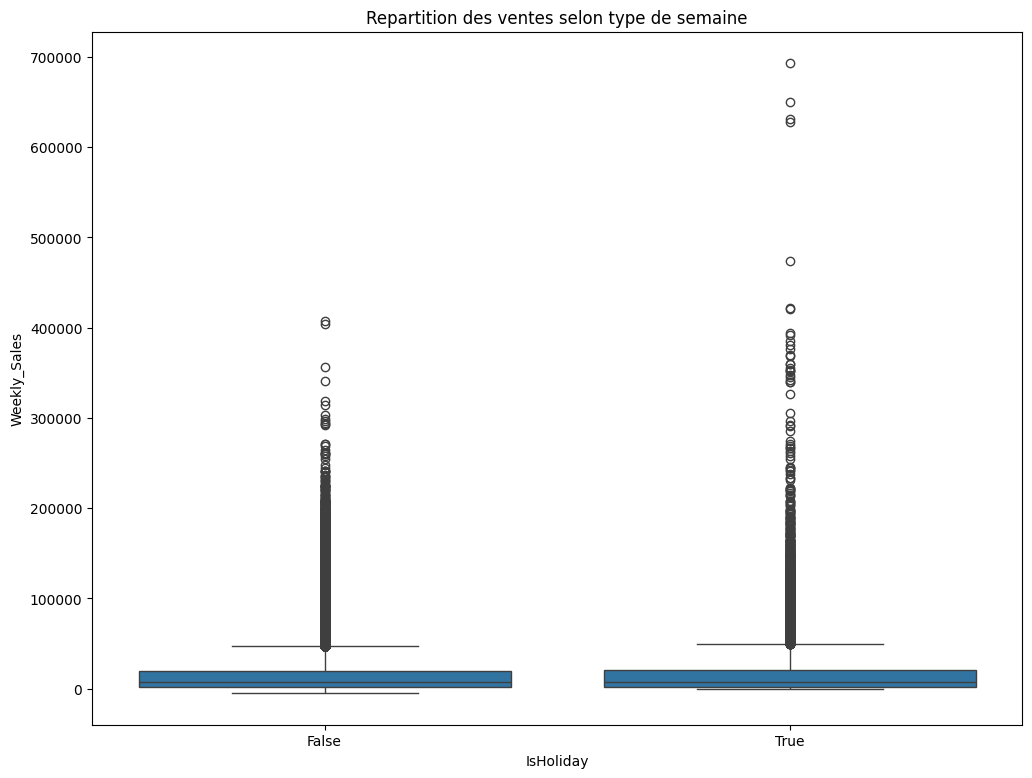

In [92]:
#Visualisons la repartion des ventes selon le type de semaine
plt.figure(figsize=(12,9))
sns.boxplot(df_train,x="IsHoliday",y="Weekly_Sales")
plt.title("Repartition des ventes selon type de semaine")
plt.show()

**D'après cette distribution Il existe des boutiques pour lesquelles certains departements lors des semaines de fêtes connaissent des ventes explosives ce qui s'explique à travers la présence de valeurs extrêmes ce qui voudrait dire que pour ces departements les ventes sont plus signicative durant les periode de fête**

## B- Etudions l'impact des fêtes sur les ventes.

**Pour cela nous allons filtrer notre jeu de données afin de travailler uniquement sur les lignes concernant les fêtes et evaluer les moyennes de ventes selon les fêtes et le type de magasin**

In [93]:
# Definissons une fonction qui nous permettra de calcules la moyenne de ventes selon differente catégorie
def mean_sales(df,liste,store="Type",sale="Weekly_Sales"):
  """
  Cette fonction permattra de calculer la moyenne de ventes selon si une variable est vrai surtout pour etudier les impact de
  cette variable sur les ventes elle prend en paramètres:
  -le dataframe de ventes
  -la liste de variables dont-on veut evaluer l'impact
  -Par defaut on a le type de magasin et les ventes par semaine
  Elle retourne un dataframe affichant les moyenne en fonction la liste passée en paramètre et le type de magasin
  """
  result={}
  for col in liste:
      data=df.loc[df[col]==1]
      result[col]=data.groupby(store)[sale].mean()
  return pd.DataFrame(result).reset_index()



In [94]:
holiday_col=["Is_SuperBowl","Is_LaborDay","Is_Chrismas","Is_Thankgiving"]
print("*"*60)
print("Moyenne des ventes selon le type de semaine")
print("*"*60)
resulr=mean_sales(df_train,holiday_col)
resulr

************************************************************
Moyenne des ventes selon le type de semaine
************************************************************


,Type,Is_SuperBowl,Is_LaborDay,Is_Chrismas,Is_Thankgiving
0,A,20603.690832,19973.219881,32936.084436,27370.728296
1,B,12401.718198,12013.482757,21893.671073,18661.296519
2,C,10156.204711,9871.225746,10399.688555,9679.900152


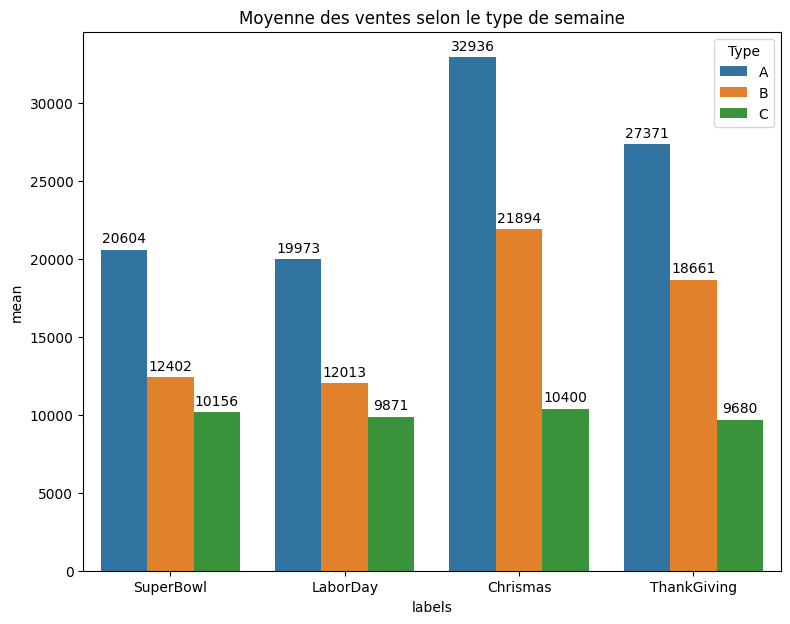

In [95]:
#from numpy._core.fromnumeric import mean
# Représentation graphique de ces valeurs
def get_store_holidayMean(df,store_name):
  holiday_col=["Is_SuperBowl","Is_LaborDay","Is_Chrismas","Is_Thankgiving"]
  return(
      df.loc[df["Type"]==store_name,holiday_col]
      .values.flatten()
      .tolist()
  )
mean_A=get_store_holidayMean(resulr,"A")
mean_B=get_store_holidayMean(resulr,"B")
mean_C=get_store_holidayMean(resulr,"C")
labels=["SuperBowl","LaborDay","Chrismas","ThankGiving"]
plot_df=pd.DataFrame({
    "labels":labels*3,
    "mean":mean_A+mean_B+mean_C,
    "Type":["A"]*4+["B"]*4+["C"]*4

})
plt.figure(figsize=(9,7))
ax=sns.barplot(plot_df,x="labels",y="mean",hue="Type")
# Annotation de chaque barre
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.title("Moyenne des ventes selon le type de semaine")
plt.show()




**On constate que :**
  * pour les magasin de type A et B les semaines de Thanksgiving sont pour lesquelles on enregistre les meilleurs ventes en moyenne
  * Par contre en ce qui concerne les boutiques de type B la semaine de fête ayant les meilleurs ventes en moyenne est celle du SuperBowl
  * Les semaines de noel semblent être celle avec le moins d'impact sur les ventes ce qui pourrait être expliqué par le fait d'une part par le fait que les données s'arrête juste en octobre 2012 et d'autre part le semaine de noel est considérée comme étant la dernière de chaque année or elle survient généralement une semaine avant
  

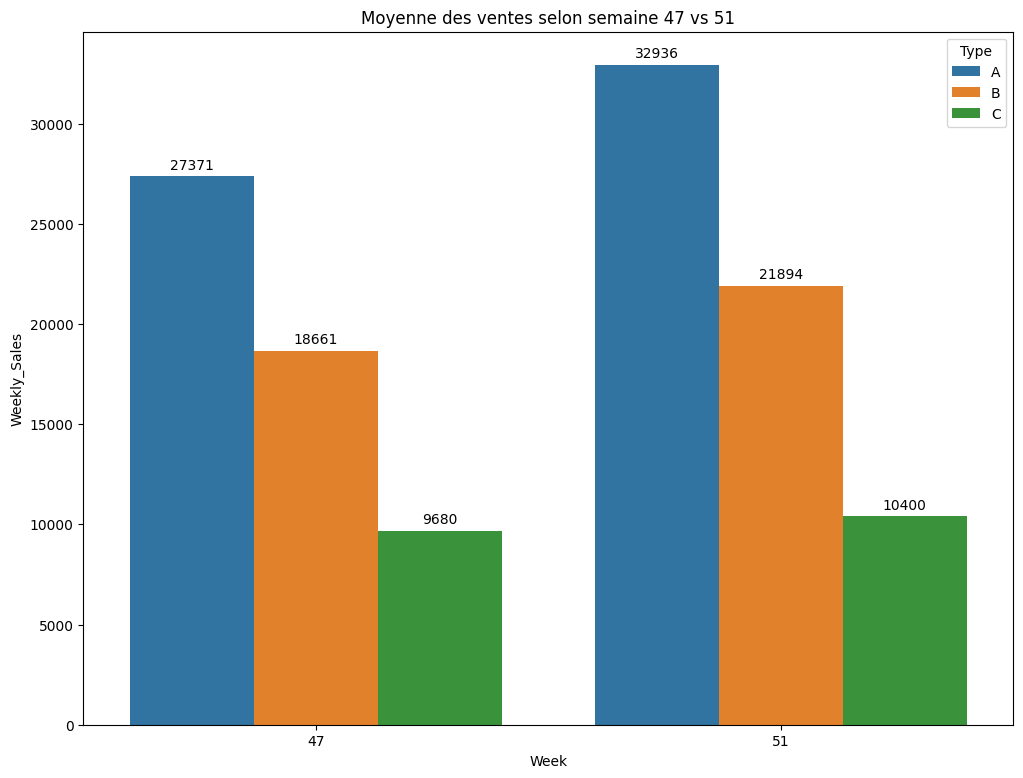

In [96]:
#Visualisons la moyenne de ventes lors des semaines 47 et 51
df_filtre=df_train.loc[df_train["Week"].isin([47,51])]
df_visi=df_filtre.groupby(["Week","Type"])["Weekly_Sales"].mean().reset_index()
df_visi.columns=["Week","Type","Weekly_Sales"]
plt.figure(figsize=(12,9))
ax=sns.barplot(df_visi,x="Week",y="Weekly_Sales",hue="Type")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.title("Moyenne des ventes selon semaine 47 vs 51")
plt.show()


**On se rend effectivement compte que les semaines de fête de noel sont celle où les ventes explosent tout autant que thanksgiving**

In [97]:
print("*"*30)
print("Top 10 des ventes par semaine")
print("*"*30)
top5 = (
    df_train[["Store","Dept","Date","Weekly_Sales","IsHoliday","Is_SuperBowl","Is_LaborDay","Is_Chrismas","Is_Thankgiving"]]
    .sort_values("Weekly_Sales", ascending=False)
    .head(10)
)
top5

******************************
Top 10 des ventes par semaine
******************************


,Store,Dept,Date,Weekly_Sales,IsHoliday,Is_SuperBowl,Is_LaborDay,Is_Chrismas,Is_Thankgiving
95373,10,72,2010-11-26,693099.36,True,0,0,0,1
338013,35,72,2011-11-25,649770.18,True,0,0,0,1
95425,10,72,2011-11-25,630999.19,True,0,0,0,1
337961,35,72,2010-11-26,627962.93,True,0,0,0,1
135665,14,72,2010-11-26,474330.10,True,0,0,0,1
195088,20,72,2010-11-26,422306.25,True,0,0,0,1
264390,27,72,2010-11-26,420586.57,True,0,0,0,1
88428,10,7,2010-12-24,406988.63,False,0,0,1,0
95377,10,72,2010-12-24,404245.03,False,0,0,1,0
214432,22,72,2010-11-26,393705.20,True,0,0,0,1


**Sans surprise on se rend tout de suite compte que les meilleurs ventes presque toujours en Thanksgiving sur les 10 meilleures semaines de ventes au cours de ces 03 années seules deux diffèrent de la semaine de Thanksgiving et elle concerne par contre les semaines de veilles de noêl cela prouve une fois de plus que les semaines de thanksgiving sont très importantes**

**Par ailleurs on constate que le departement 72 est un departement ayant de top ventes hebdomadaire cela voudrait certainement dire que ce departement possède la majeur partir des articles sollicités en thanksgiving**

In [98]:
print("*"*30)
print("Flop 10 des ventes par semaine")
print("*"*30)
tail5=(
    df_train.loc[df_train["Is_Vente"]==1,["Store","Dept","Date","Weekly_Sales","IsHoliday","Is_SuperBowl","Is_LaborDay","Is_Chrismas","Is_Thankgiving"]]
    .sort_values("Weekly_Sales",ascending=False)
    .tail(10)
)
tail5

******************************
Flop 10 des ventes par semaine
******************************


,Store,Dept,Date,Weekly_Sales,IsHoliday,Is_SuperBowl,Is_LaborDay,Is_Chrismas,Is_Thankgiving
370916,39,99,2010-04-23,0.01,False,0,0,0,0
197508,20,99,2011-04-15,0.01,False,0,0,0,0
78656,8,99,2012-10-26,0.01,False,0,0,0,0
370915,39,99,2010-03-26,0.01,False,0,0,0,0
266943,27,99,2010-04-09,0.01,False,0,0,0,0
237059,24,99,2010-10-22,0.01,False,0,0,0,0
303787,31,99,2010-02-05,0.01,False,0,0,0,0
303788,31,99,2010-02-12,0.01,True,1,0,0,0
256749,26,99,2012-08-10,0.01,False,0,0,0,0
107898,11,99,2012-09-28,0.01,False,0,0,0,0


**Le department le moins rentable semble être le 99 qui d'ailleurs est celui qui enregistre les 10 mauvaise ventes, ces ventes surviennent presque toujours durant les semaines ordinaires cela renforce d'avantage l'importance des fêtes sur le revenu hebdomadaire**

**Essayons d'analyser Si cela n'est peut-être pas du aussi à l'absence de promotion afin de booster les ventes de ce departement**

In [99]:
dept_99=df_train.loc[df_train["Dept"]==99].sort_values("Weekly_Sales",ascending=False)
print(f"Nomnbre de vente pour le departement 99: {dept_99.shape[0]}")
print(f"Nombre de vente du departement ayant au moins une promotion: {dept_99.loc[dept_99['Promotion_Active']==1].shape[0]}")
print(f"Pourcentage de semaine de vente du departement 99 ayant au moins une promotion: {(dept_99.loc[dept_99['Promotion_Active']==1].shape[0]/dept_99.shape[0])*100:.2f}% ")
dept_99.head()



Nomnbre de vente pour le departement 99: 862
Nombre de vente du departement ayant au moins une promotion: 637
Pourcentage de semaine de vente du departement 99 ayant au moins une promotion: 73.90% 


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Promotion_Active,Nombre_Promotion,MarkDown1_Active,MarkDown2_Active,MarkDown3_Active,MarkDown4_Active,MarkDown5_Active,Is_Vente,Is_SuperBowl,Is_LaborDay,Is_Chrismas,Is_Thankgiving,Years,Mois,Week
197517,20,99,2011-11-25,12550.0,True,A,203742,46.38,3.492,335.66,80.00,101378.79,64.46,2251.98,211.412076,7.082,1,5,1,1,1,1,1,1,0,0,0,1,2011,November,47
128048,13,99,2011-11-25,12225.0,True,A,219622,38.89,3.445,1282.42,548.10,109030.75,146.33,3557.67,129.836400,6.392,1,5,1,1,1,1,1,1,0,0,0,1,2011,November,47
39762,4,99,2011-12-16,8570.0,False,A,205863,36.44,3.149,2756.67,72.30,1790.15,777.65,10261.95,129.898065,5.143,1,5,1,1,1,1,1,1,0,0,0,0,2011,December,50
138092,14,99,2011-12-16,6910.0,False,A,200898,39.93,3.413,5398.47,6.12,881.17,290.64,6390.47,188.797935,8.523,1,5,1,1,1,1,1,1,0,0,0,0,2011,December,50
107871,11,99,2011-12-23,6280.0,False,A,207499,54.29,3.112,515.57,11.23,964.31,0.00,3429.82,222.825863,7.197,1,4,1,1,1,0,1,1,0,0,1,0,2011,December,51


**Environ 74% des ventes du departement 99 bénéficie d'au moins une promotion mais cela n'a néanmoins aucune influence significative ce departement rencontre des difficulté à commercialiser ces articles**

### C. Impact des promotions sur les ventes

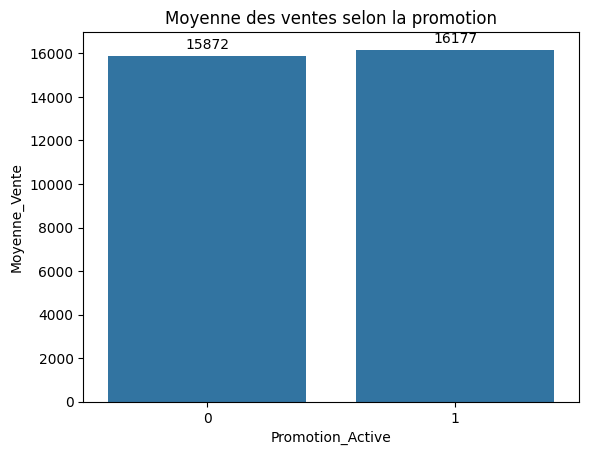

In [100]:
#Repartition des moyenne des ventes selon la promotion
df_moy= df_train.groupby("Promotion_Active")["Weekly_Sales"].mean().reset_index()
df_moy.columns=["Promotion_Active","Moyenne_Vente"]
ax=sns.barplot(df_moy,x="Promotion_Active",y="Moyenne_Vente")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
    plt.title("Moyenne des ventes selon la promotion")
plt.show()


In [101]:
print("*"*60)
print("Nombre de semaines sans promotion VS avec au moins une promotion")
print("*"*60)
df_train.groupby("Promotion_Active")["Weekly_Sales"].count()

************************************************************
Nombre de semaines sans promotion VS avec au moins une promotion
************************************************************


Promotion_Active
0    270138
1    151432
Name: Weekly_Sales, dtype: int64

### C.1- TEST STATISTIQUE
##### Z test

In [102]:
!pip install statsmodels


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [103]:
# Z test
# Hypothèse nulle
print("H0: la moynne des ventes sans promotion est égale à la moyenne des ventes avec promotion")
# Hypothèse alternative
print("H1: la moyenne des ventes sans promotion est inferieure de la moyenne des ventes avec promotion")

from statsmodels.stats.weightstats import ztest
ventes_avec=df_train.loc[df_train["Promotion_Active"]==1,"Weekly_Sales"]
ventes_sans=df_train.loc[df_train["Promotion_Active"]==0,"Weekly_Sales"]
test=ztest(ventes_sans,ventes_avec,alternative="smaller")
if test[1]>0.05:
  print("Pas de différence significative")
else :
  print("\nLa moyenne de vente sans promotion est inferieure à la moyenne de ventes avec promtion")
  print(f"\nLe p-value est de {test[1]}")

H0: la moynne des ventes sans promotion est égale à la moyenne des ventes avec promotion
H1: la moyenne des ventes sans promotion est inferieure de la moyenne des ventes avec promotion

La moyenne de vente sans promotion est inferieure à la moyenne de ventes avec promtion

Le p-value est de 1.3934003089112984e-05


### C.2 Quel est la promotion la plus fructueuse

In [104]:
import statsmodels.formula.api as smf
# Liste des colonnes de promotions
markdown_cols = [
    "MarkDown1_Active","MarkDown2_Active","MarkDown3_Active",
    "MarkDown4_Active","MarkDown5_Active"
]
# 1. ETUDE STATISTIQUE SIMPLE : Z-TEST PAR STORE × DEPT × PROMOTION
results_simple = []  # Stockage des résultats du test simple
for store in df_train["Store"].unique():           # Parcours des magasins
    for dept in df_train["Dept"].unique():         # Parcours des départements
        # Sous-échantillon : uniquement les ventes effectives
        data = df_train.loc[
            (df_train["Store"] == store) &
            (df_train["Dept"] == dept) &
            (df_train["Weekly_Sales"] > 0)
        ]
        if data.empty:
            continue  # Aucun point de données → on passe
        for md in markdown_cols:
            # Ventes avec promotion active
            vente_avec = data.loc[data[md] == 1, "Weekly_Sales"]
            # Ventes sans promotion
            vente_sans = data.loc[data[md] == 0, "Weekly_Sales"]
            # On ne teste que si les deux groupes sont suffisants
            if len(vente_avec) > 5 and len(vente_sans) > 5:
                z, p = ztest(vente_sans, vente_avec, alternative="smaller")
                # Stockage : Store, Dept, Promotion, p-value
                results_simple.append([store, dept, md, p])

 # 2. ETUDE STATISTIQUE AVEC MODELE : OLS (Store + Dept + Saisonnalité)
results_model = []  # Stockage des résultats du modèle
# Création d'un flag numérique pour les jours fériés
df_train["Holiday_Flag"] = df_train["IsHoliday"].astype(int)
for md in markdown_cols:
    # Modèle OLS intégrant Store, Dept, Holiday, Week, Years
    formula = (
        f"Weekly_Sales ~ {md} + C(Store) + C(Dept) + Holiday_Flag + Week + Years"
    )
    model = smf.ols(formula, data=df_train).fit()
    # Extraction du coefficient et de la p-value de la promotion
    coef = model.params.get(md, None)
    p_value = model.pvalues.get(md, None)
    results_model.append([md, coef, p_value])
# 3. CONSTRUCTION DES DATAFRAMES RESULTATS
df_simple = pd.DataFrame(
    results_simple,
    columns=["Store", "Dept", "Promotion", "p_value"]
)
df_simple["Significatif"] = df_simple["p_value"] < 0.05

df_model = pd.DataFrame(
    results_model,
    columns=["Promotion", "Effet", "p_value"]
)
df_model["Significatif"] = df_model["p_value"] < 0.05

# Nettoyage : suppression de la colonne temporaire
df_train.drop(columns=["Holiday_Flag"], inplace=True)


In [105]:
df_simple.head(50)

,Store,Dept,Promotion,p_value,Significatif
0,1,1,MarkDown1_Active,4.543929e-01,False
1,1,1,MarkDown2_Active,5.331217e-01,False
2,1,1,MarkDown3_Active,4.068939e-01,False
3,1,1,MarkDown4_Active,4.543929e-01,False
4,1,1,MarkDown5_Active,4.543929e-01,False
5,1,2,MarkDown1_Active,1.953654e-02,True
6,1,2,MarkDown2_Active,2.191373e-02,True
7,1,2,MarkDown3_Active,2.318514e-02,True
8,1,2,MarkDown4_Active,1.953654e-02,True
9,1,2,MarkDown5_Active,1.953654e-02,True


**Ce Dataframe nous permettra de visualiser à travers un heatmap l'impact de chacune des promotions en fonction des departements**

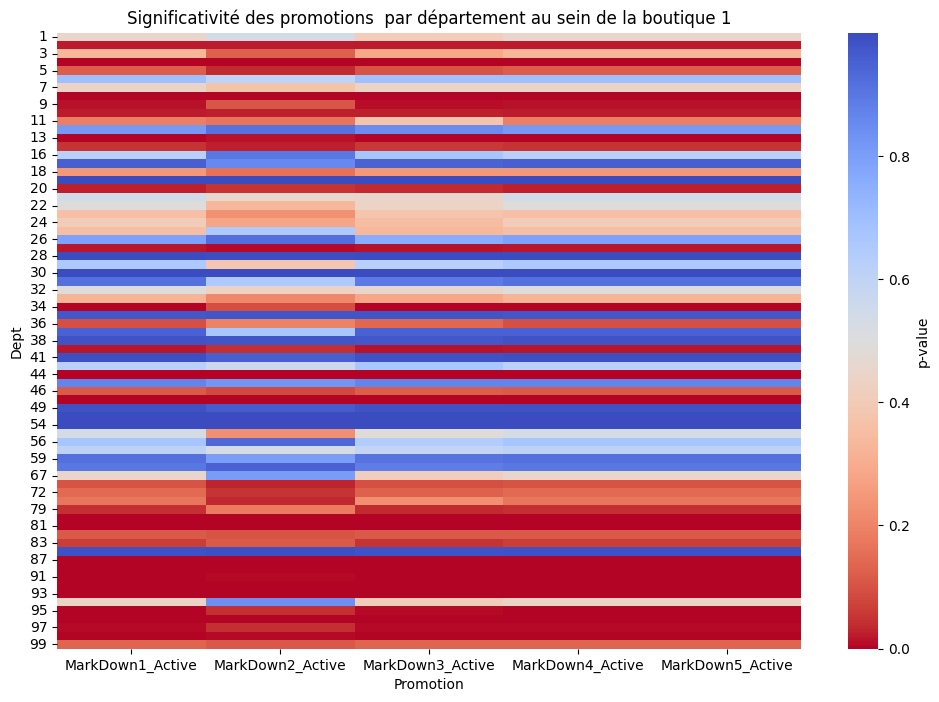

In [106]:
pivot = df_simple[df_simple['Store']==1].pivot(index="Dept", columns="Promotion", values="p_value")

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap="coolwarm_r", cbar_kws={'label': 'p-value'})
plt.title("Significativité des promotions  par département au sein de la boutique 1")
plt.show()


In [107]:
df_model

,Promotion,Effet,p_value,Significatif
0,MarkDown1_Active,1662.948696,8.268883e-101,True
1,MarkDown2_Active,996.212599,5.905105e-58,True
2,MarkDown3_Active,1427.131488,1.278459e-93,True
3,MarkDown4_Active,1339.246556,1.953917e-75,True
4,MarkDown5_Active,1670.279610,2.009593e-100,True


### D. Performance par boutique.

**Nous allons determiner la ou les boutiques ayant la grande moyenne globale de vente**

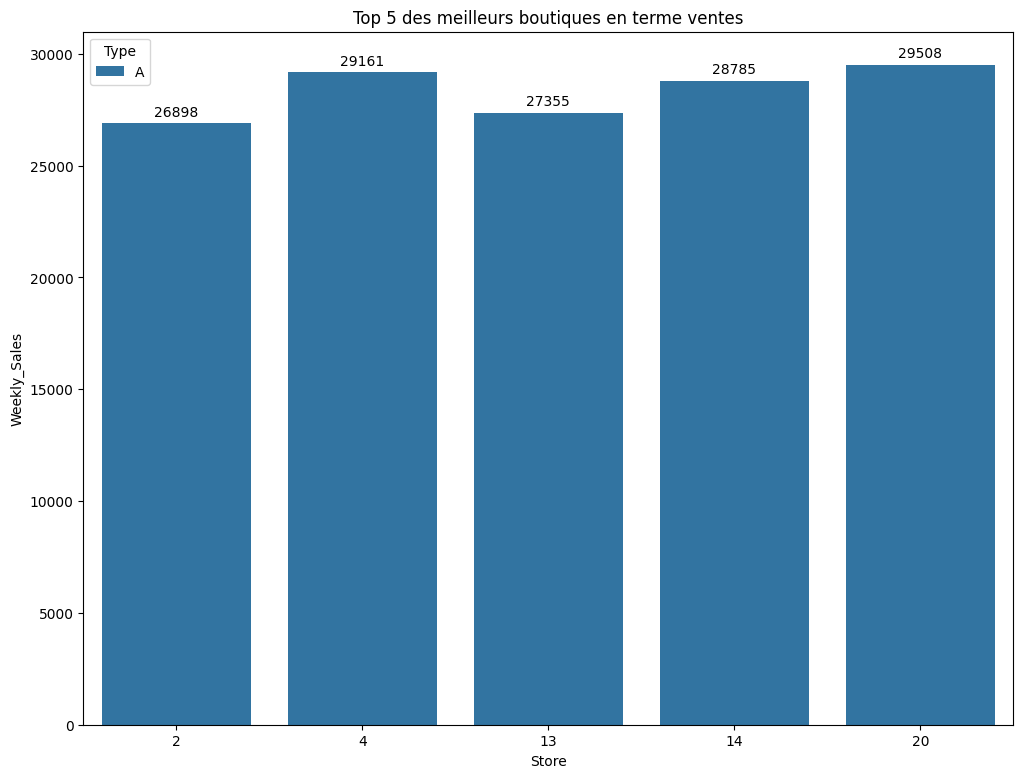

In [108]:
store=df_train.groupby(["Store","Type"])["Weekly_Sales"].mean().reset_index()
plt.figure(figsize=(12,9))
ax=sns.barplot(store.sort_values("Weekly_Sales",ascending=False).head(5),x="Store",y="Weekly_Sales",hue="Type")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
    plt.title("Top 5 des meilleurs boutiques en terme ventes")
plt.show()


In [109]:
### B.1 Évaluons la progression de ces boutiques en fonction du temps

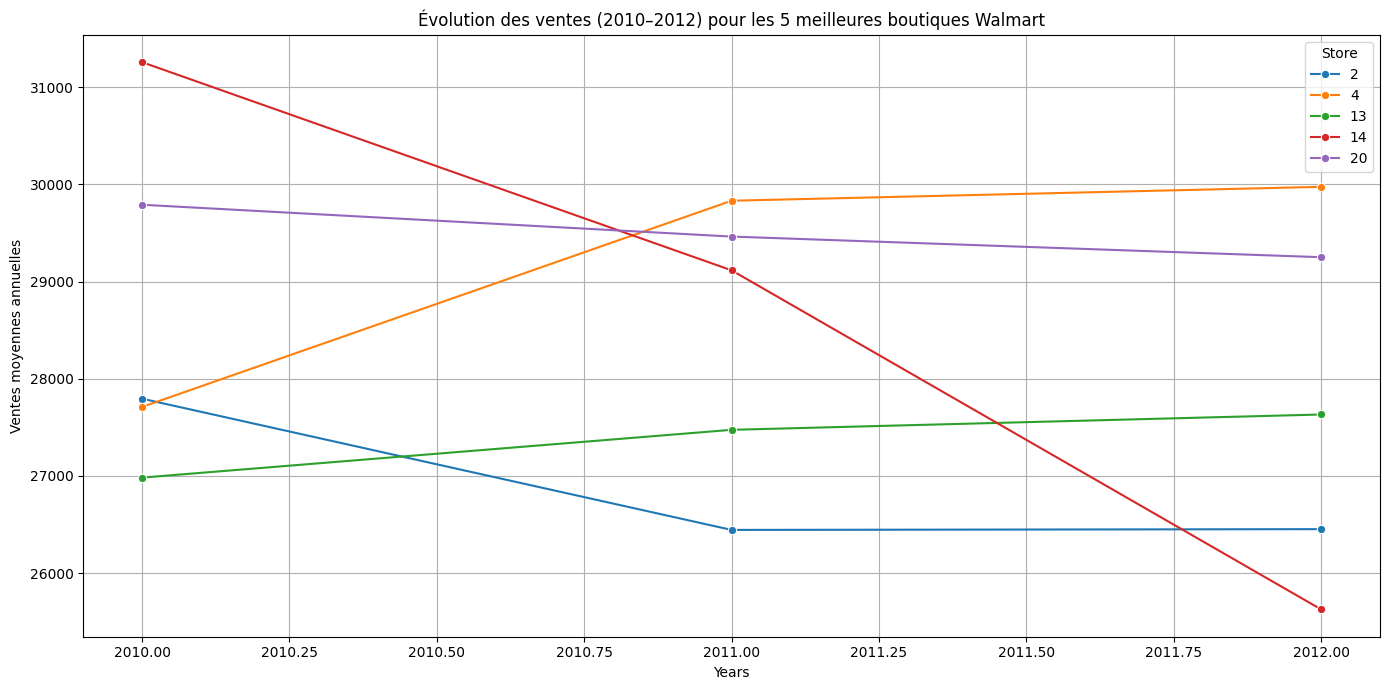

In [110]:
#Évaluons la progression de ventes de ces boutiques en fonction du temps
# Filtrer uniquement les 5 meilleures boutiques
# Recuperons le top 5 des boutiques
top5_store=store.sort_values("Weekly_Sales",ascending=False).head(5)
#Recuperons tous les informations de ces 5 boutiques
df_top5=df_train.loc[df_train["Store"].isin(top5_store["Store"])]
# Agréger les ventes par Store et par Date
df_time = (
    df_top5
    .groupby(["Years", "Store"])["Weekly_Sales"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_time,
    x="Years",
    y="Weekly_Sales",
    hue="Store",
    palette="tab10",
    marker="o"
)

plt.title("Évolution des ventes (2010–2012) pour les 5 meilleures boutiques Walmart")
plt.xlabel("Years")
plt.ylabel("Ventes moyennes annuelles")
plt.grid(True)
plt.tight_layout()
plt.show()


### B.2 Pour chacune de ces boutiques determinons les meilleurs departements

C:\Users\Owner\AppData\Local\Temp\ipykernel_47980\2936722101.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(top5_dept,x="Dept",y="Weekly_Sales",palette="viridis")


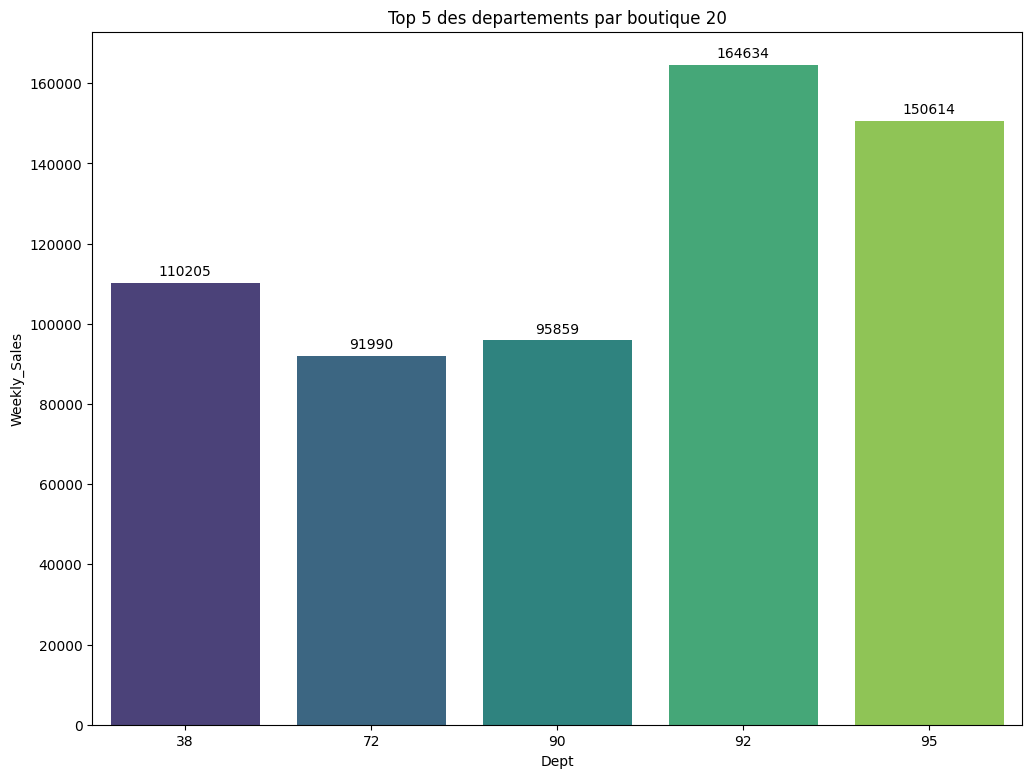

C:\Users\Owner\AppData\Local\Temp\ipykernel_47980\2936722101.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(top5_dept,x="Dept",y="Weekly_Sales",palette="viridis")


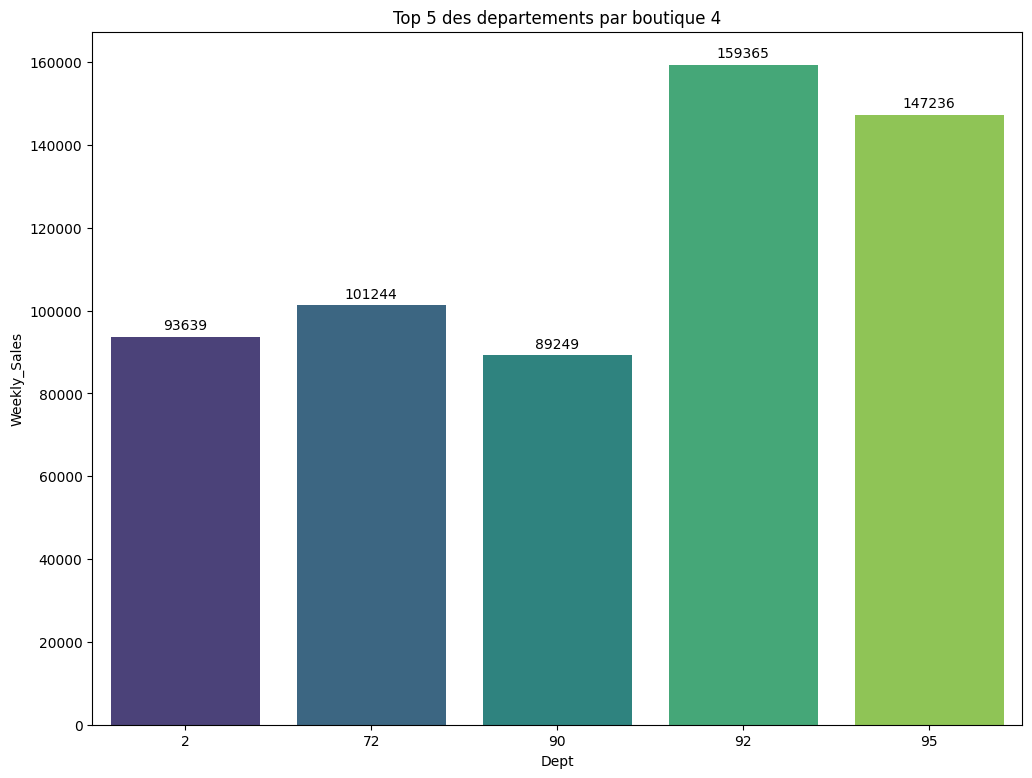

C:\Users\Owner\AppData\Local\Temp\ipykernel_47980\2936722101.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(top5_dept,x="Dept",y="Weekly_Sales",palette="viridis")


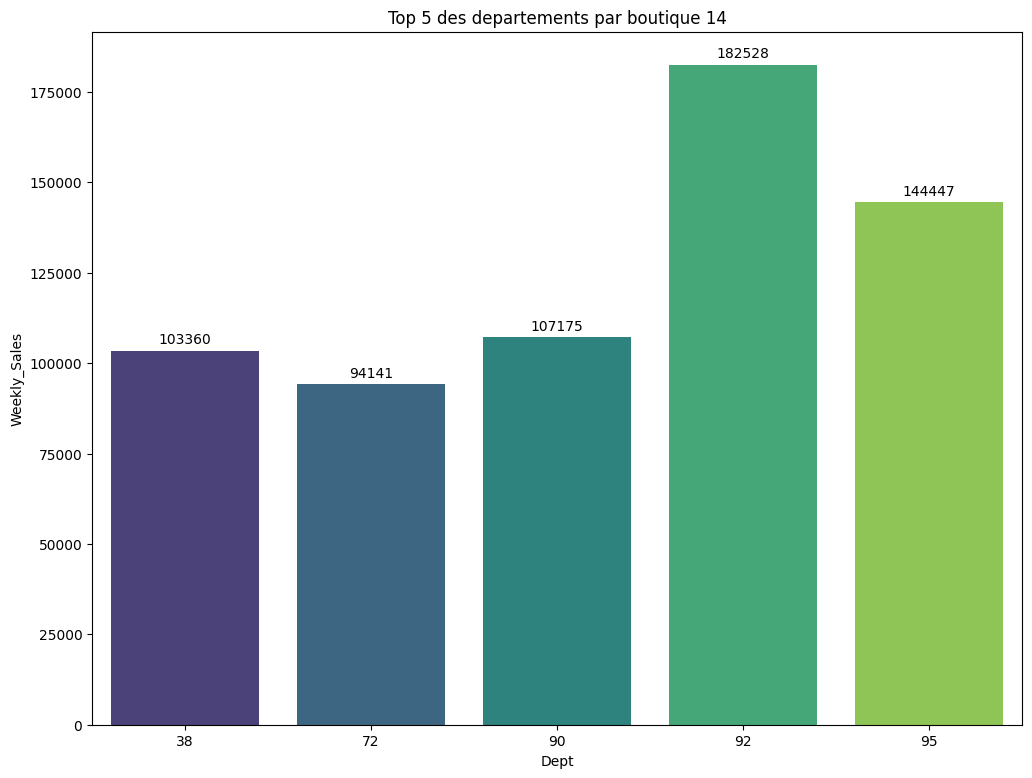

C:\Users\Owner\AppData\Local\Temp\ipykernel_47980\2936722101.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(top5_dept,x="Dept",y="Weekly_Sales",palette="viridis")


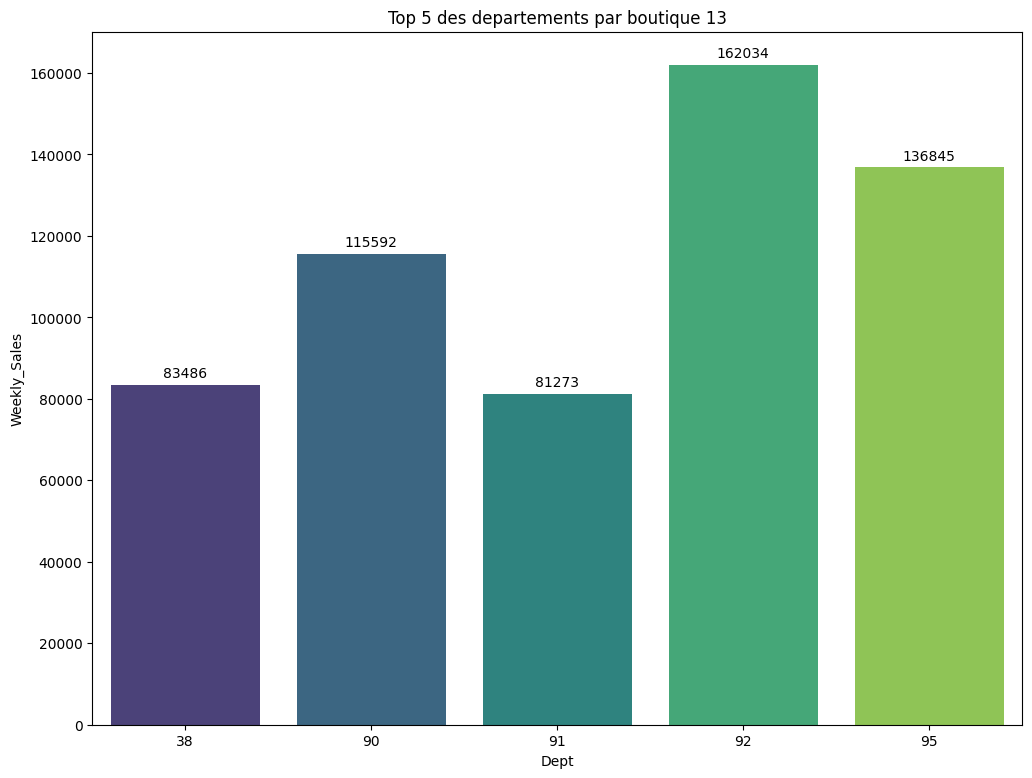

C:\Users\Owner\AppData\Local\Temp\ipykernel_47980\2936722101.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(top5_dept,x="Dept",y="Weekly_Sales",palette="viridis")


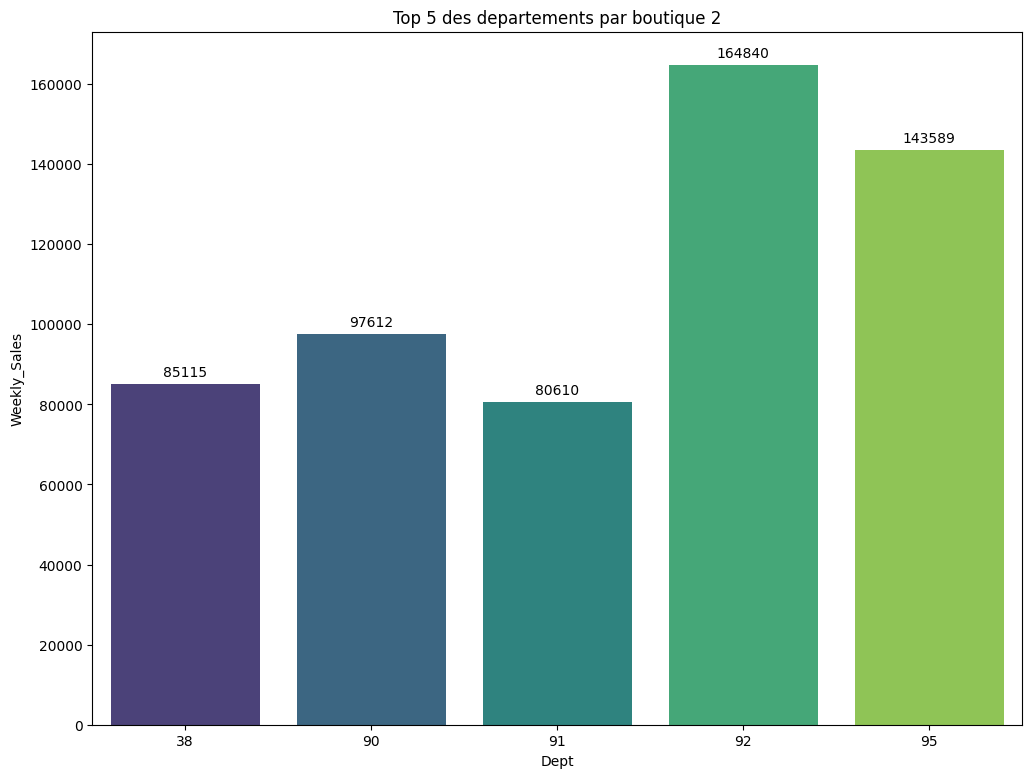

In [111]:
#Visualisons le top 5 des departement par boutique
for st in top5_store["Store"]:
  stre=df_top5.loc[df_top5["Store"]==st]
  top5_dept=stre.groupby(["Store","Dept"])["Weekly_Sales"].mean().reset_index().sort_values("Weekly_Sales",ascending=False).head(5)
  plt.figure(figsize=(12,9))
  ax=sns.barplot(top5_dept,x="Dept",y="Weekly_Sales",palette="viridis")
  for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
    plt.title(f"Top 5 des departements par boutique {st}")
  plt.show()


### E. Distribution temporelle

In [112]:
!pip install nbformat


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [113]:
# Création d'une date continue basée sur Year + Week
df_train["Date_Week"] = (
    pd.to_datetime(df_train["Years"].astype(str) + "-1", format="%Y-%w")
    + pd.to_timedelta((df_train["Week"] - 1) * 7, unit="D")
)
# Agrégation hebdomadaire
weekly_sales = (
    df_train
    .groupby("Date_Week", as_index=False)["Weekly_Sales"]
    .sum()
)
# Graphique : une seule ligne continue
fig = px.line(
    weekly_sales,
    x="Date_Week",
    y="Weekly_Sales",
    markers=True,
    title="Évolution continue des ventes hebdomadaires (2010 → 2012)"
)
fig.update_xaxes(title="Temps (Années)")
fig.update_yaxes(title="Ventes totales")
fig.update_layout(
    plot_bgcolor="white",
    hovermode="x unified"
)
fig.show()
df_train.drop(columns=["Date_Week"], inplace=True)

**Analyse de cette progression de ventes révèle une tendance cyclique des ventes, en effet les pic sont toujours atteint lors de la 51 ième et 47 ième semaine mais aussi on observe une chute remarquable en debut d'année**

## E Analyse Temporelle de Is_vente=0

**Il s'agit de voir si les retours ou l'absence de vente suit un cycle**

In [114]:
#Nombre de retours enregistré par semaine de facon globale
retour_temps=df_train[df_train["Is_Vente"]==0].groupby("Date").size().reset_index(name="Nombre_retours")
fig=px.line(retour_temps,x="Date",y="Nombre_retours",
            title="Évolution du nombre de retours par rapport au temps")
fig.show()

**On constate des retours reguliers chaques fin d'année c'est certainement la raison pour laquelle les ventes sont faibles en janvier au sorti des fêtes de fin d'années les gens achète moins où effectue les retours plus de retours**

**Modèle comprendras que janvier est un mois où les ventes sont très bas**

**On constate également qu'autours du mois de Mai on enregistre aussi beaucoup de retours**

## Implémentation et évaluation d'un modèle de machine  learning

**Avant de passer au modèle nous allons créer de nouvelle variable lag1, lag4 et lag52 afin d'aider le modèle à capturer ces tendances observées plus haut sur les ventes**

**La Création de ces variables Lag génère plusieurs ligne avec de valeurs manquantes mais ce ne sont réellement pas de valeurs manquantes. Nous procederons à la gestion de ces valeurs manquantes avant tout implémentation de modèle**



**Afin de pallier au problème d'identifiant des stores et departement nous allons proceder à un target encoding en considerant uniquement les paramètres calculer sur les données d'entrainements**

**Pour cela nous allons definir une fonction target_encoding que nous exploiterons après la séparation des données d'entrainement et validation**

## Preparation des données pour le modèle

**Plusieurs des variables ont été créées juste pour nous faciliter l'exercice de l'exploration des données cependant nous allons proceder à la creation de nouvelle variables afin de permettre au modèle de comprendre ce phénomène cyclique tandencieux qui s'y degage**

### 4. Features Engineering

## 4.1 Encodage de Departement et Store  

In [115]:
#Définissons la fonction target_encoding:
def target_encoding(train, test):
  """
  Cette fonction p map respectivement
  chaque store et departement par la moyennne de vente ce departement au sein du store. cette moyennes sera uniquement calculée sont les données d'entrainement
  Paramètre: dataframe
    - train: dataframe d'entrainement
    - test: dataframe de test
  retourne: dataframe
    - train: dataframe d'entrainement avec les departements par store encodés
    - test: dataframe de test
  """
  #Encodage des dept en fonction des boutiques
  mean_combined = train.groupby(["Store", "Dept"])["Weekly_Sales"].mean().reset_index()
  mean_combined.rename(columns={'Weekly_Sales': 'Store_Dept_Encoded'}, inplace=True)
  train = train.merge(mean_combined, on=["Store", "Dept"], how="left")
  test = test.merge(mean_combined, on=["Store", "Dept"], how="left")


  # Remplissage des manquants pour le combiné
  test["Store_Dept_Encoded"] = test["Store_Dept_Encoded"].fillna(train["Weekly_Sales"].mean())
  return train, test

### 4.2 Transformation Logarithmique de la variable Weekly_Sales

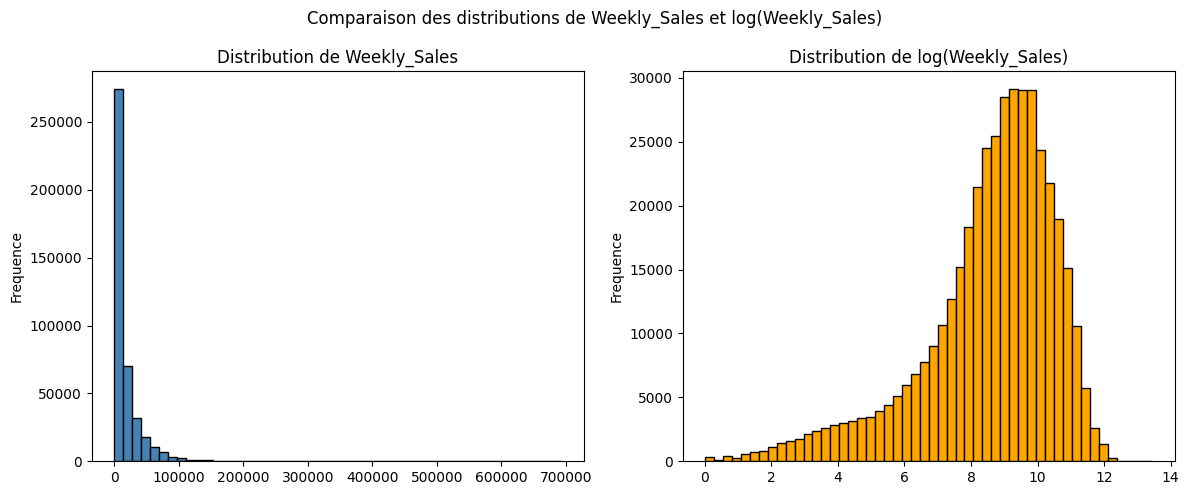

In [116]:
#Transformation logarithmique de Weekly_Sales
df_train=df_train[df_train["Weekly_Sales"]>0]
df_train["Target"]=np.log1p(df_train["Weekly_Sales"])
#Visualisation des deux distribution sur une même figure
fig,ax=plt.subplots(1,2,figsize=(12,5))
ax[0].hist(df_train["Weekly_Sales"],bins=50,color="steelblue",edgecolor="black")
ax[0].set_title("Distribution de Weekly_Sales")
ax[0].set_ylabel("Frequence")
ax[1].hist(df_train["Target"],bins=50,color="orange",edgecolor="black")
ax[1].set_title("Distribution de log(Weekly_Sales)")
ax[1].set_ylabel("Frequence")
plt.suptitle("Comparaison des distributions de Weekly_Sales et log(Weekly_Sales)")
plt.tight_layout()
plt.show()



## 4.3 Création des variables Lag permettant de capturer la notion du passé

In [120]:
def feature_engineering(df):
  """
  Cette fonction nous permettra de definir des variables permettant de capturer la notion du passé
  Paramètre: dataframe
    - df: dataframe d'entrainement
  retourne: dataframe
  """
  df=df.copy()
  df=df.sort_values(["Store","Dept","Date"]).reset_index(drop=True)
  df["Mois"]=df["Date"].dt.month
  #---1. Variables Lag 1,2 et 4
  print(f"Nombre de ligne Avant features engineering: {df.shape[0]}")
  for lag in [1,2,4]:
    df[f"Lag_{lag}"]=df.groupby(["Store","Dept"])["Weekly_Sales"].shift(lag)

  #---2. Moyenne roulante 4 et 8 on utilisera shit 1 pour eviter le data leakage
  for window in  [4,8]:
    df[f"Rolling_mean_{window}"]=df.groupby(["Store","Dept"])["Weekly_Sales"].transform(lambda x: x.shift(1).rolling(window,min_periods=1).mean())
    df[f"Rolling_std_{window}"]=df.groupby(["Store","Dept"])["Weekly_Sales"].transform(lambda x: x.shift(1).rolling(window,min_periods=1).std())

  #--3. Encodage Cyclique des variables temporelles
  df["Week_sin"]=np.sin(2*np.pi*df["Week"]/52)
  df["Week_cos"]=np.cos(2*np.pi*df["Week"]/52)
  df["Month_sin"]=np.sin(2*np.pi*df["Mois"]/12)
  df["Month_cos"]=np.cos(2*np.pi*df["Mois"]/12)

  #-- 4. Nettoyage des valeurs manquante générée par les Lags
  df=df.dropna(subset=[f"Lag_{l}" for l in [1,2,4]]).reset_index(drop=True)

  print(f"Nombre de ligne Après features engineering: {df.shape[0]}")
  print(20*"*"+"Features Engineering Terminé"+20*"*")
  return df



# Fonction du split temporel

def split_temporel(df,ratio=0.8):
  df=df.copy()
  df["Mois"]=df["Date"].dt.month
  df=df.sort_values("Date").reset_index(drop=True)
  date_min=df["Date"].min()
  date_max=df["Date"].max()
  range_date=(date_max-date_min).days
  split=date_min+pd.Timedelta(days=int(range_date*ratio))
  train=df.loc[df["Date"]<split].copy()
  test=df.loc[df["Date"]>=split].copy()
  print(f"Train: { date_min} à { train['Date'].max()}")
  print(f"Test: { test['Date'].min()} a { date_max}")
  return train, test


# Métriques et Visualisation

def gestion_metrique(y_true,y_pred,model_name="Modèle"):
  """
  Calcule et Affiche les métriques principales
  retourne le dictionnaire des métriques

  """
  rmse=np.sqrt(mean_squared_error(y_true,y_pred))
  mae=mean_absolute_error(y_true,y_pred)
  r2=r2_score(y_true,y_pred)
  print(f"\n{'='*50}")
  print(f"{model_name}")
  print(f"{'='*50}")
  print(f"RMSE : { rmse:.2f}")
  print(f"MAE : {mae:.2f}")
  print(f"R2 : {r2:.2f}")
  return {"model": model_name, "RMSE": rmse, "MAE": mae, "R2": r2}



def plot_predictions(y_true, y_pred, model_name, dates=None):
    """Visualise les prédictions vs valeurs réelles."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f" {model_name} — Analyse des prédictions", fontsize=14, fontweight="bold")

    # Courbe temporelle
    x = dates if dates is not None else np.arange(len(y_true))
    axes[0].plot(x, y_true,  label="Réel",    color="steelblue", alpha=0.8)
    axes[0].plot(x, y_pred,  label="Prédit",  color="darkorange", alpha=0.8, linestyle="--")
    axes[0].set_title("Valeurs réelles vs prédites")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Weekly Sales")
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=30)

    # Scatter plot
    axes[1].scatter(y_true, y_pred, alpha=0.3, color="steelblue", s=10)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[1].plot(lim, lim, "r--", label="Parfait")
    axes[1].set_title("Réel vs Prédit (scatter)")
    axes[1].set_xlabel("Réel")
    axes[1].set_ylabel("Prédit")
    axes[1].legend()

    plt.tight_layout()
    plt.show()



def plot_learning_curve_rf_xgb(model, X, y, model_name, cv):
    """Learning curve pour modèles sklearn-compatibles (RF, XGB).
       Vérification de overfitting ou UnderFitting RF et XGB
    """
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(10, 5))
    plt.plot(train_sizes, train_mean, "o-", color="steelblue", label="R² Train")
    plt.plot(train_sizes, val_mean,   "o-", color="darkorange", label="R² Validation")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="steelblue")
    plt.fill_between(train_sizes, val_mean - val_std,   val_mean + val_std,   alpha=0.15, color="darkorange")

    gap = train_mean[-1] - val_mean[-1]
    if gap > 0.1:
        diagnostic = f" Overfitting (gap train-val = {gap:.3f})"
    elif val_mean[-1] < 0.7:
        diagnostic = f" Underfitting (R² val = {val_mean[-1]:.3f})"
    else:
        diagnostic = f" Bon équilibre (R² val = {val_mean[-1]:.3f})"

    plt.title(f"Learning Curve — {model_name}\n{diagnostic}")
    plt.xlabel("Taille du jeu d'entraînement")
    plt.ylabel("R²")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return diagnostic





def plot_keras_history(history, model_name):
    """Visualise les courbes loss train/val pour CNN et LSTM."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f" {model_name} — Courbes d'apprentissage", fontsize=13, fontweight="bold")

    # Loss
    axes[0].plot(history.history["loss"],     label="Train Loss",      color="steelblue")
    axes[0].plot(history.history["val_loss"], label="Validation Loss", color="darkorange")
    axes[0].set_title("Loss (MSE)")
    axes[0].set_xlabel("Epochs")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # MAE
    if "mae" in history.history:
        axes[1].plot(history.history["mae"],     label="Train MAE",      color="steelblue")
        axes[1].plot(history.history["val_mae"], label="Validation MAE", color="darkorange")
        axes[1].set_title("MAE")
        axes[1].set_xlabel("Epochs")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    # Diagnostic overfitting/underfitting
    final_train_loss = history.history["loss"][-1]
    final_val_loss   = history.history["val_loss"][-1]
    ratio = final_val_loss / (final_train_loss + 1e-9)
    if ratio > 1.3:
        diag = f"Attention Overfitting (val_loss / train_loss = {ratio:.2f})"
    elif final_train_loss > 0.1:
        diag = "Attention Underfitting (loss train encore élevée)"
    else:
        diag = f" Bon équilibre (ratio = {ratio:.2f})"

    fig.text(0.5, -0.02, f"Diagnostic : {diag}", ha="center", fontsize=11,
             color="red" if "Attention" in diag else "green")
    plt.tight_layout()
    plt.show()









#gestion des valeurs manquantes generer par les variables lags

def gestion_missing_values(df,col=["Lag_1","Lag_2","Lag_4"]):
  mean_store=df.groupby(["Store"])["Weekly_Sales"].mean() # moyenne de ventes par store
  for col in col:
    df[col]=df.groupby(["Store","Dept"])[col].transform(lambda x: x.fillna(x.mean()))  #imputation des valeurs manquantes
    if df[col].isna().sum()>0:             #si a jamais un departement est supprimé au cours d'une annnée
      df[col]=df[col].fillna(df["Store"].map(mean_store))    #On remplacera la valeurs manquante par la moyenne de vente de la boutique
  return df




### Modèle 1 Random Forest Regressor

In [121]:
def run_random_forest(X_train, y_train, X_val, y_val, feature_names, dates_val=None):
    print("\n" + "="*60)
    print(" RANDOM FOREST REGRESSOR")
    print("="*60)

    tscv = TimeSeriesSplit(n_splits=5)

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=5,
        max_features=0.5,
        oob_score=False,    # désactivé car données temporelles
        random_state=42,
        n_jobs=-1
    )

    # Learning curve AVANT le fit final  et cv temporel
    plot_learning_curve_rf_xgb(rf, X_train, y_train, "Random Forest", tscv)

    # Fit final sur tout X_train
    rf.fit(X_train, y_train)

    # Métriques
    y_pred_train = rf.predict(X_train)
    y_pred_val   = rf.predict(X_val)
    metrics_train = gestion_metrique(y_train, y_pred_train, "RF — Train")
    metrics_val   = gestion_metrique(y_val,   y_pred_val,   "RF — Validation")

    # Prédictions visuelles
    y_pred_orig = np.expm1(y_pred_val)  #  retour en dollars
    y_true_orig = np.expm1(y_val)  #  retour en dollars
    plot_predictions(y_true_orig, y_pred_orig, "Random Forest", dates=dates_val)

    # Feature importance
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    plt.barh(imp_df["feature"], imp_df["importance"], color="steelblue")
    plt.gca().invert_yaxis()
    plt.title(" Feature Importance — Random Forest")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    return rf, {"train": metrics_train, "val": metrics_val}


### Modèle 2 XGBoost Regressor

In [122]:
def run_xgboost(X_train, y_train, X_val, y_val, feature_names, dates_val=None):
    print("\n" + "="*60)
    print(" XGBOOST REGRESSOR")
    print("="*60)

    xgb_model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        early_stopping_rounds=30,
        eval_metric="rmse",
        random_state=42,
        n_jobs=-1
    )

    # eval_set = holdout temporel → remplace learning_curve

    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=50
    )

    #  Courbe native XGBoost — équivalent de la learning curve pour le boosting
    results   = xgb_model.evals_result()
    best_iter = xgb_model.best_iteration
    best_train = results["validation_0"]["rmse"][best_iter]
    best_val   = results["validation_1"]["rmse"][best_iter]
    gap        = best_val - best_train   #  val - train (positif si overfit)

    if gap > 500:
        diag = f" Overfitting (gap val-train = {gap:,.0f})"
    elif best_val > 5000:
        diag = " Underfitting (RMSE val encore élevée)"
    else:
        diag = f" Bon équilibre — meilleure itération : {best_iter}"

    plt.figure(figsize=(10, 5))
    plt.plot(results["validation_0"]["rmse"], label="Train RMSE", color="steelblue")
    plt.plot(results["validation_1"]["rmse"], label="Val RMSE",   color="darkorange")
    plt.axvline(best_iter, color="red", linestyle="--", label=f"Best iter ({best_iter})")
    plt.title(f"XGBoost — RMSE par itération\n{diag}")
    plt.xlabel("Itérations")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Métriques
    y_pred_train = xgb_model.predict(X_train)
    y_pred_val   = xgb_model.predict(X_val)
    metrics_train = gestion_metrique(y_train, y_pred_train, "XGB — Train")
    metrics_val   = gestion_metrique(y_val,   y_pred_val,   "XGB — Validation")

    # Prédictions visuelles
    y_pred_orig = np.expm1(y_pred_val)  #  retour en dollars
    y_true_orig = np.expm1(y_val)                 #  retour en dollars
    plot_predictions(y_true_orig, y_pred_orig, "XGBoost", dates=dates_val)


    # Feature importance
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": xgb_model.feature_importances_
    }).sort_values("importance", ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    plt.barh(imp_df["feature"], imp_df["importance"], color="darkorange")
    plt.gca().invert_yaxis()
    plt.title(" Feature Importance — XGBoost")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    return xgb_model, {"train": metrics_train, "val": metrics_val}

### Préparation Séquence pour CNN et LSTM

In [123]:
def create_sequences_by_group(df_raw, X_scaled, y_scaled, seq_len=8):
    """
    Crée les séquences en respectant les groupes Store × Dept.
    df_raw  : dataframe original (avec colonnes Store, Dept, Date)
    X_scaled: numpy array des features normalisées
    y_scaled: numpy array de la cible normalisée
    """
    Xs, ys = [], []
    df_raw=df_raw.reset_index(drop=True)

    for (store, dept), group in df_raw.groupby(["Store", "Dept"]):
        idx = group.sort_values("Date").index.to_numpy()         # indices triés par date
        X_g = X_scaled[idx]
        y_g = y_scaled[idx]

        if len(X_g) <= seq_len:                        # groupe trop court  on ignore
            continue

        for i in range(seq_len, len(X_g)):
            Xs.append(X_g[i - seq_len:i])
            ys.append(y_g[i])

    return np.array(Xs), np.array(ys)

### Modèle 3 CNN

In [124]:
def run_cnn(df_train_raw,val_df_raw,X_train_raw, y_train_raw, X_val_raw, y_val_raw,
            seq_len=8, epochs=100, batch_size=256, dates_val=None):
    print("\n" + "="*60)
    print(" CNN — 1D Temporal Convolutional Network")
    print("="*60)

    # Normalisation
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_sc = scaler_X.fit_transform(X_train_raw)
    X_val_sc   = scaler_X.transform(X_val_raw)
    y_train_sc = scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1)).flatten()
    y_val_sc   = scaler_y.transform(y_val_raw.values.reshape(-1, 1)).flatten()

    # Création des séquences
    X_tr_seq, y_tr_seq = create_sequences_by_group(df_train_raw,X_train_sc, y_train_sc, seq_len)
    X_vl_seq, y_vl_seq = create_sequences_by_group(val_df_raw,X_val_sc,   y_val_sc,   seq_len)

    print(f"   Shape séquences train : {X_tr_seq.shape}")
    print(f"   Shape séquences val   : {X_vl_seq.shape}")

    n_features = X_tr_seq.shape[2]

    # Architecture CNN
    model = Sequential([
        Conv1D(filters=64,  kernel_size=3, activation="relu", padding="same", input_shape=(seq_len, n_features)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2, padding="same"),
        Conv1D(filters=128, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2, padding="same"),
        Conv1D(filters=64,  kernel_size=3, activation="relu", padding="same"),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(64,  activation="relu"),
        Dense(1)
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss="mse", metrics=["mae"])
    model.summary()

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6)
    ]

    history = model.fit(
        X_tr_seq, y_tr_seq,
        validation_data=(X_vl_seq, y_vl_seq),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    # Courbes d'apprentissage + diagnostic
    plot_keras_history(history, "CNN 1D")

    # Métriques en scale original
    y_pred_sc    = model.predict(X_vl_seq).flatten()
    y_pred_orig  = scaler_y.inverse_transform(y_pred_sc.reshape(-1, 1)).flatten()
    y_true_orig  = scaler_y.inverse_transform(y_vl_seq.reshape(-1, 1)).flatten()
    y_pred_orig = np.expm1(y_pred_orig)  #  retour en dollars
    y_true_orig = np.expm1(y_true_orig)                 #  retour en dollars

    metrics_val = gestion_metrique(y_true_orig, y_pred_orig, "CNN — Validation")

    # Prédictions visuelles
    dates_cnn = dates_val.iloc[seq_len:].reset_index(drop=True) if dates_val is not None else None
    plot_predictions(pd.Series(y_true_orig), pd.Series(y_pred_orig), "CNN 1D", dates=dates_cnn)

    return model, scaler_X, scaler_y, {"val": metrics_val}

### Modèle 4 LSTM

In [125]:
def run_lstm(df_train_raw,val_df_raw,X_train_raw, y_train_raw, X_val_raw, y_val_raw,
             seq_len=8, epochs=100, batch_size=256, dates_val=None):
    print("\n" + "="*60)
    print(" LSTM — Long Short-Term Memory")
    print("="*60)

    # Normalisation
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_sc = scaler_X.fit_transform(X_train_raw)
    X_val_sc   = scaler_X.transform(X_val_raw)
    y_train_sc = scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1)).flatten()
    y_val_sc   = scaler_y.transform(y_val_raw.values.reshape(-1, 1)).flatten()

    # Séquences
    X_tr_seq, y_tr_seq = create_sequences_by_group(df_train_raw,X_train_sc, y_train_sc, seq_len)
    X_vl_seq, y_vl_seq = create_sequences_by_group(val_df_raw,X_val_sc,   y_val_sc,   seq_len)

    print(f"   Shape séquences train : {X_tr_seq.shape}")
    print(f"   Shape séquences val   : {X_vl_seq.shape}")

    n_features = X_tr_seq.shape[2]

    # Architecture LSTM
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(seq_len, n_features)),
        Dropout(0.2),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss="mse", metrics=["mae"])
    model.summary()

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6)
    ]

    history = model.fit(
        X_tr_seq, y_tr_seq,
        validation_data=(X_vl_seq, y_vl_seq),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    # Courbes d'apprentissage + diagnostic
    plot_keras_history(history, "LSTM")

    # Métriques en scale original
    y_pred_sc   = model.predict(X_vl_seq).flatten()
    y_pred_orig = scaler_y.inverse_transform(y_pred_sc.reshape(-1, 1)).flatten()
    y_true_orig = scaler_y.inverse_transform(y_vl_seq.reshape(-1, 1)).flatten()

    metrics_val = gestion_metrique(y_true_orig, y_pred_orig, "LSTM — Validation")

    # Prédictions visuelles
    y_true_orig = np.expm1(y_true_orig)                 #  retour en dollars
    y_pred_orig = np.expm1(y_pred_orig)  #  retour en dollars
    dates_lstm = dates_val.iloc[seq_len:].reset_index(drop=True) if dates_val is not None else None
    plot_predictions(pd.Series(y_true_orig), pd.Series(y_pred_orig), "LSTM", dates=dates_lstm)

    return model, scaler_X, scaler_y, {"val": metrics_val}

### Comparaison des modèles

In [126]:
def plot_comparaison(all_metrics):
    """
    Affiche un tableau comparatif des métriques de tous les modèles.
    all_metrics : liste de dicts {"model", "RMSE", "MAE", "R2", "WMAPE"}
    """
    df_comp = pd.DataFrame(all_metrics)
    df_comp = df_comp.set_index("model")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(" Comparaison des modèles — Métriques de validation", fontsize=14, fontweight="bold")

    colors = ["steelblue", "darkorange", "seagreen", "mediumpurple"]

    for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
        vals = df_comp[metric]
        bars = ax.bar(vals.index, vals.values, color=colors[:len(vals)])
        ax.set_title(metric)
        ax.set_ylabel(metric)
        for bar, val in zip(bars, vals.values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.01,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9)
        ax.tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()

    print("\n Tableau récapitulatif :")
    print(df_comp.to_string())
    return df_comp


Pipeline finale

In [127]:
# --- Préparation ---
le=LabelEncoder()
df_train["Type"]=le.fit_transform(df_train["Type"])  # cet encodage sera conservé pour le deploiement
df = feature_engineering(df_train)
train_df, val_df = split_temporel(df, ratio=0.8)
train_df,val_df=target_encoding(train_df,val_df)   #Target encoding des stores et departement

FEATURES = [
    "Store", "Dept", "Size", "Type",
    "IsHoliday", "Is_SuperBowl", "Is_LaborDay", "Is_Chrismas", "Is_Thankgiving",
    "Temperature", "Fuel_Price", "CPI", "Unemployment",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "Promotion_Active", "Nombre_Promotion", "Is_Vente",
    "Years", "Week_sin", "Week_cos", "Month_sin", "Month_cos",
    "Lag_1", "Lag_2", "Lag_4",
    "Rolling_mean_4", "Rolling_mean_8",
    "Rolling_std_4",  "Rolling_std_8","Store_Dept_Encoded"
]

TARGET = "Target"

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_val   = val_df[FEATURES]
y_val   = val_df[TARGET]
dates_val = val_df["Date"].reset_index(drop=True)

all_metrics = []











Nombre de ligne Avant features engineering: 420212
Nombre de ligne Après features engineering: 407117
********************Features Engineering Terminé********************
Train: 2010-03-05 00:00:00 à 2012-04-13 00:00:00
Test: 2012-04-20 00:00:00 a 2012-10-26 00:00:00



 RANDOM FOREST REGRESSOR


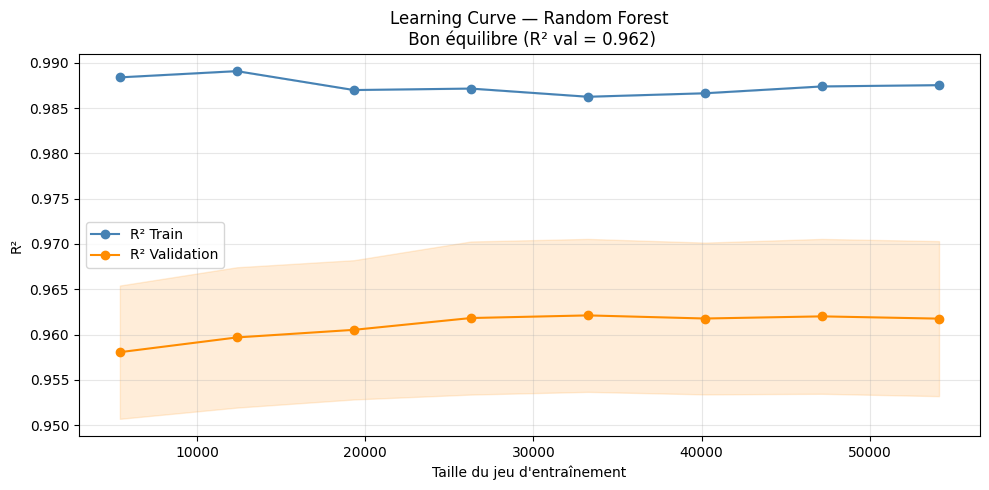


RF — Train
RMSE : 0.24
MAE : 0.13
R2 : 0.99

RF — Validation
RMSE : 0.36
MAE : 0.18
R2 : 0.97


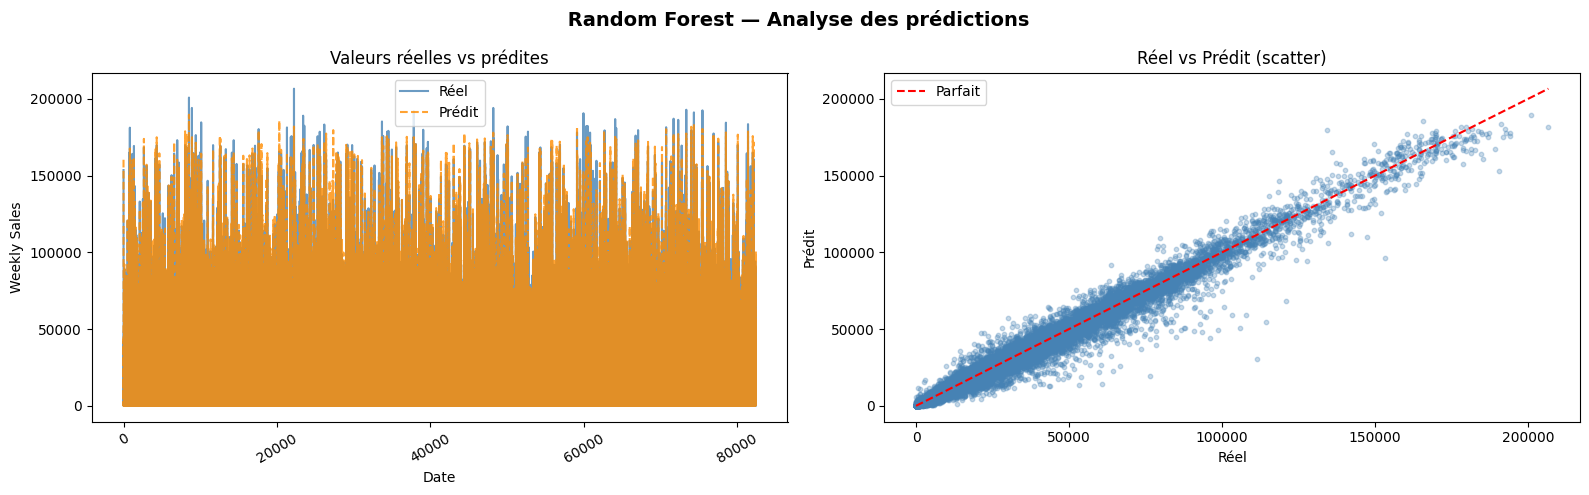

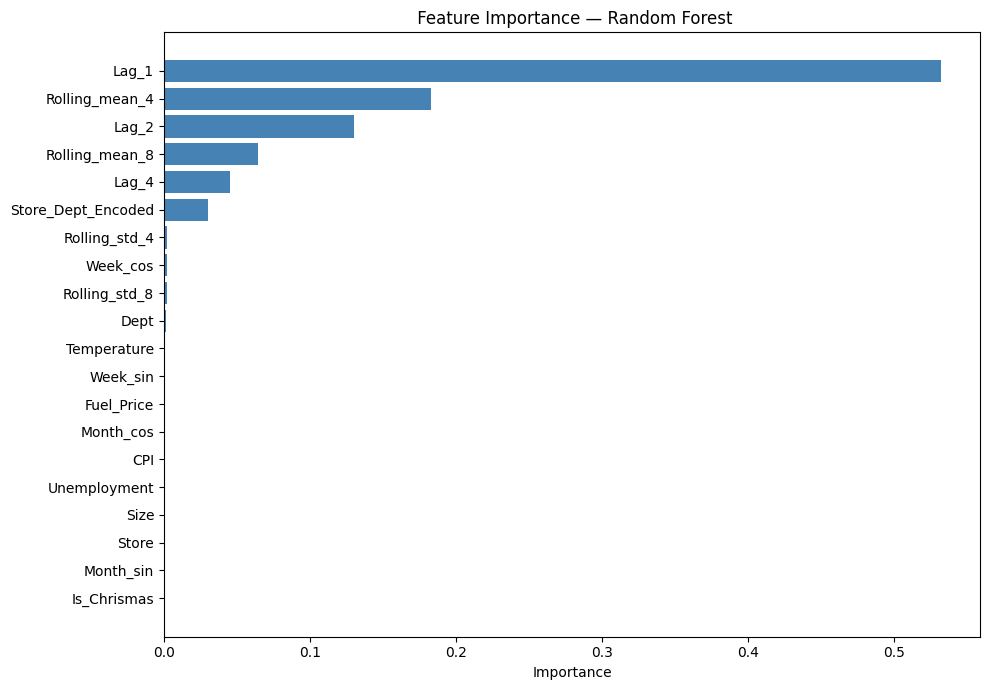

In [128]:
# --- Random Forest ---
rf_model, rf_metrics = run_random_forest(X_train, y_train, X_val, y_val, FEATURES, dates_val=None)
all_metrics.append(rf_metrics["val"])


 XGBOOST REGRESSOR
[0]	validation_0-rmse:1.88650	validation_1-rmse:1.97038
[50]	validation_0-rmse:0.37874	validation_1-rmse:0.40562
[100]	validation_0-rmse:0.33016	validation_1-rmse:0.36844
[150]	validation_0-rmse:0.32009	validation_1-rmse:0.36667
[200]	validation_0-rmse:0.31322	validation_1-rmse:0.36427
[250]	validation_0-rmse:0.30669	validation_1-rmse:0.36485
[263]	validation_0-rmse:0.30539	validation_1-rmse:0.36538


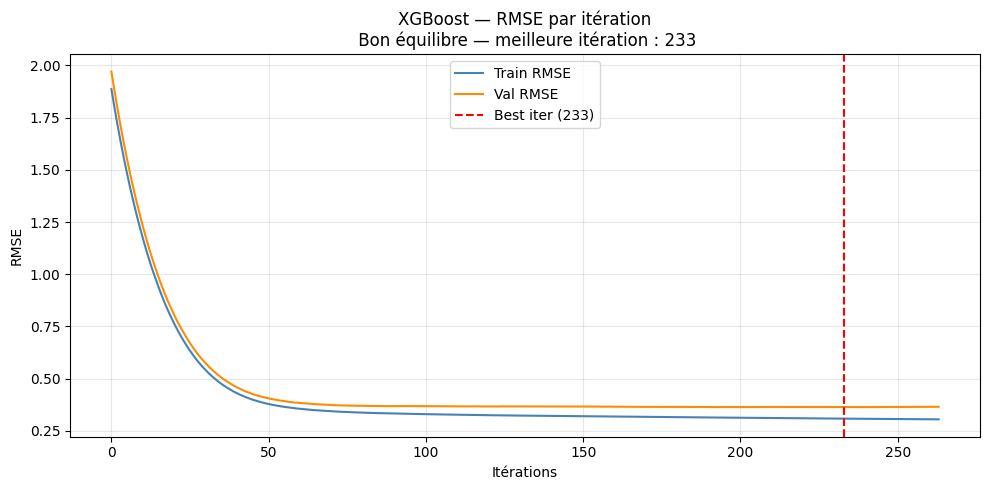


XGB — Train
RMSE : 0.31
MAE : 0.17
R2 : 0.98

XGB — Validation
RMSE : 0.36
MAE : 0.18
R2 : 0.97


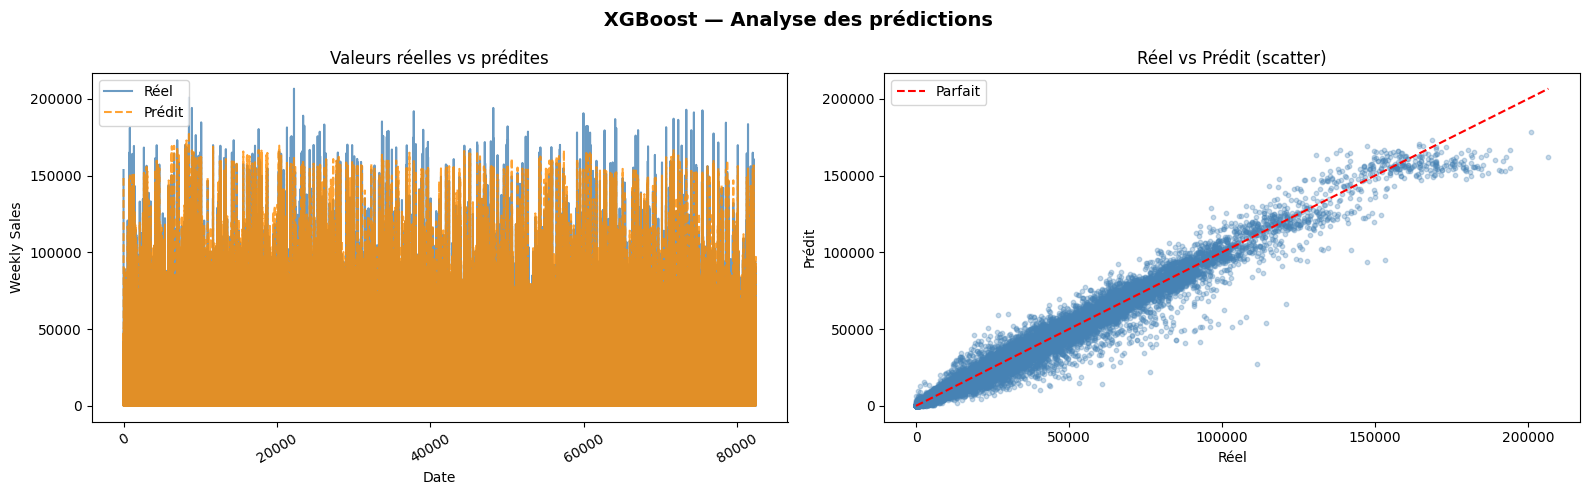

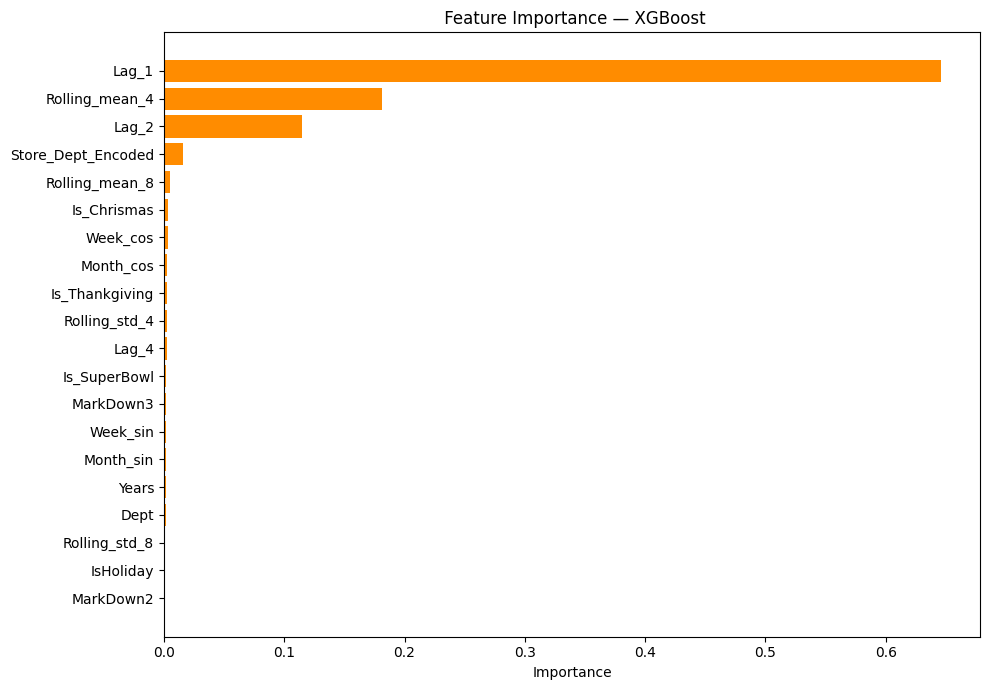

In [129]:
# --- XGBoost ---
xgb_model, xgb_metrics = run_xgboost(X_train, y_train, X_val, y_val, FEATURES, dates_val=None)
all_metrics.append(xgb_metrics["val"])